In [ ]:
import pandas as pd
import os
import json
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
import seaborn as sns
import matplotlib.pyplot as plt
import pydeseq2 as deseq2
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from pydeseq2.preprocessing import deseq2_norm

from custom_functions import *

save_format = "svg"

In [ ]:
# paths
data_dir = "../data"

# create results subfolders
results_dir = "../results"
plots_dir = f"{results_dir}/plots"
os.makedirs(f"{plots_dir}", exist_ok=True)

# Load data

## Bulk gastruloid
For this analysis, we will only retain the samples from the 72h and the initial condition at 48h, immediately before Chiron treatment.

In [ ]:
#Counts
df_gastruloid = pd.read_csv(f"{data_dir}/wnt_nodal_rnaseq/counts_chir_act_project.csv",index_col=0).T
df_gastruloid = df_gastruloid.loc[:,~df_gastruloid.columns.duplicated()].copy() #Remove potentially duplicated genes names 
df_gastruloid.rename(columns={'T': 'Tbxt'}, inplace=True)


#Metadata
df_gastruloid_metadata = pd.read_csv(f"{data_dir}/wnt_nodal_rnaseq/chir_act_metadata.csv",index_col=0)

# marker genes
marker_genes = json.load(open(f"{data_dir}/marker_genes.json"))

# Preprocessing and QC

**DATASET EXPLORATION**

In [ ]:
print(f"Samples in dataset: {df_gastruloid.shape[0]}")
print(f"Genes in dataset: {df_gastruloid.shape[1]}")

Samples in dataset: 66
Genes in dataset: 55367


**LIBRARY SIZES**

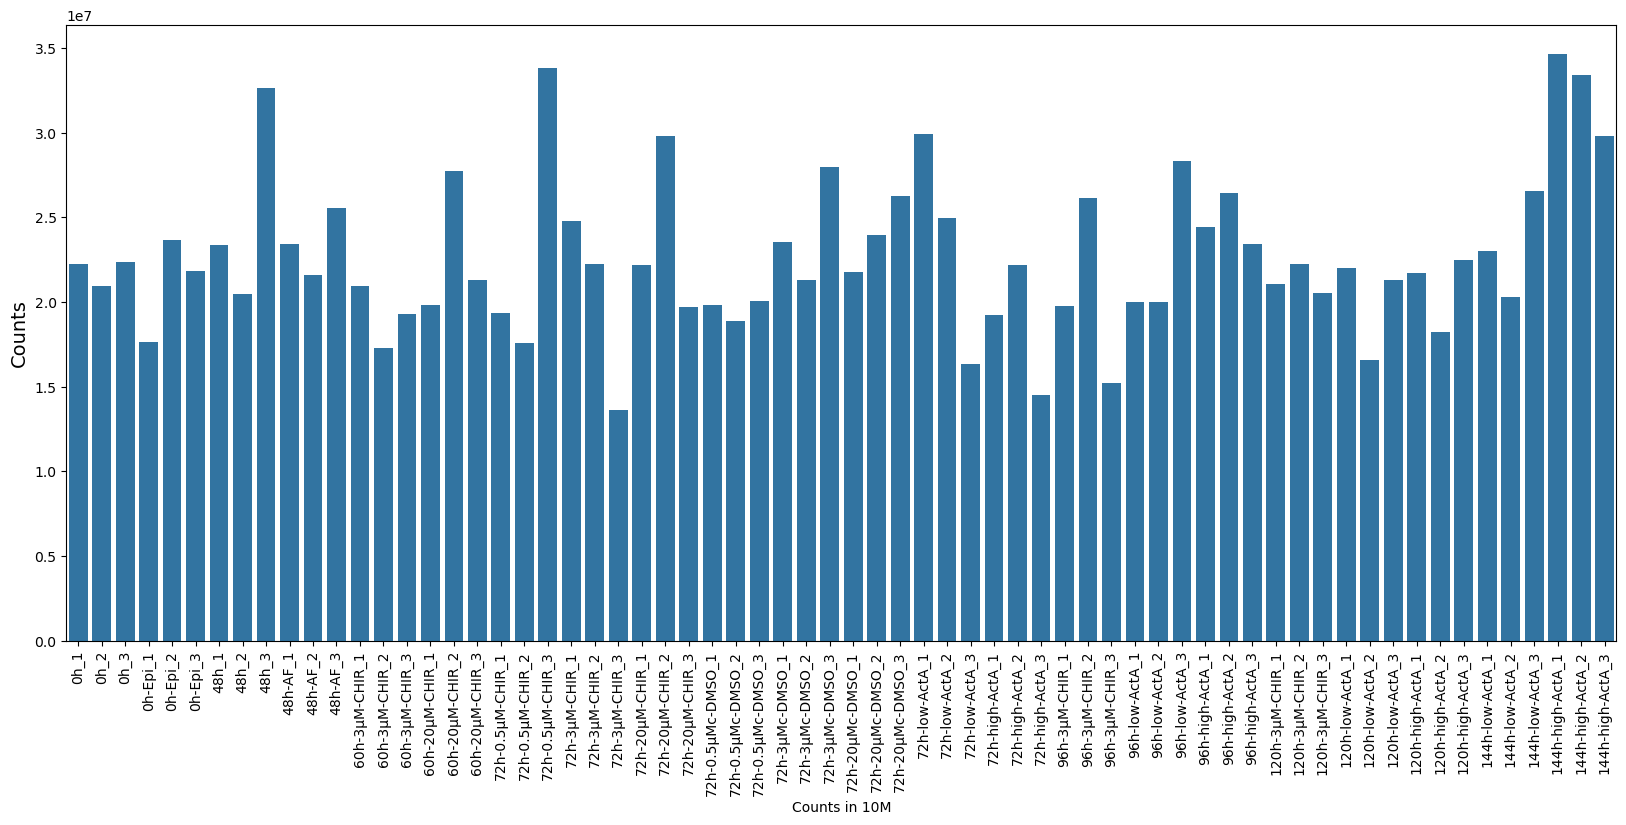

In [ ]:
fig,ax=plt.subplots(1,1,figsize=(20,8))
sns.barplot(df_gastruloid, x=df_gastruloid.index, y=df_gastruloid.sum(axis=1),ax=ax)

plt.xticks(rotation=90)
plt.xlabel('Counts in 10M')
plt.ylabel('Counts', size=14)

# create result folder
plt.savefig(f"{plots_dir}/bulk_library_sizes.{save_format}")

**LOGCOUNTS DISTRIBUTION**

In [ ]:
#LOGSCALING
log_df=np.log1p(df_gastruloid)

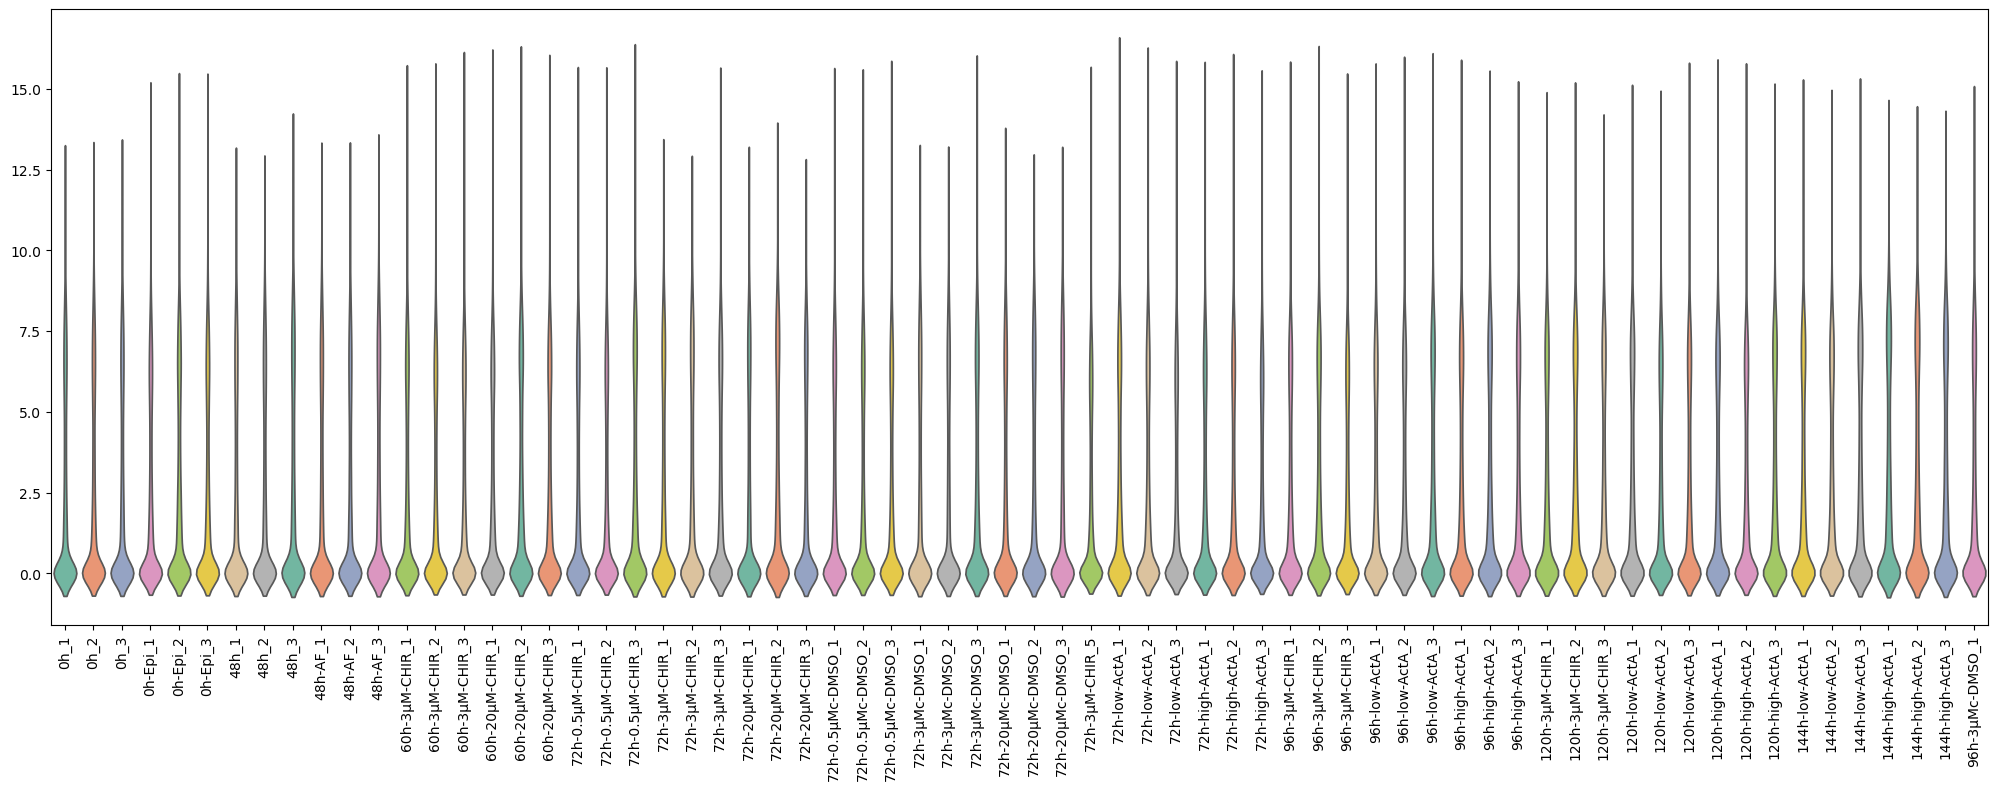

In [ ]:
fig,ax=plt.subplots(1,1,figsize=(25,8))

sns.violinplot(log_df.T, palette='Set2',inner=None,ax=ax)
plt.xticks(rotation=90)

plt.savefig(f"{plots_dir}/bulk_logcounts_distribution.{save_format}")

**NORMALIZED COUNTS**

Size factor normalization by median of ratios method

In [ ]:
# run deseq2_norm fucntion
dds_norm=deseq2_norm(df_gastruloid)

dds_norm[0].T.to_csv(f"{results_dir}/normalized_counts.csv")

**SAMPLE REMOVAL**

Remove **48h_AF** and **0h_Epi** conditions for the main analysis (later used for supplementary figures)

In [ ]:
#Retain only samples of interest
#Counts
df_gastruloid = df_gastruloid.loc[[(("AF" not in i) and ("Epi" not in i)) and (("ActA" not in i)) and (("96h" not in i)) and (("120h" not in i)) and (("CHIR_5" not in i)) for i in df_gastruloid.index.values]]
#Metadata
df_gastruloid_metadata = df_gastruloid_metadata.loc[[(("AF" not in i) and ("Epi" not in i)) and (("ActA" not in i)) and (("96h" not in i)) and (("120h" not in i)) and (("CHIR_5" not in i)) for i in df_gastruloid_metadata.index]]

# Analysis

## Construct DESeq2 object

In [ ]:
dds = DeseqDataSet(
    counts=df_gastruloid.values,
    metadata=df_gastruloid_metadata,
    design_factors="Condition",
    refit_cooks=True
)

/home/pau/.local/share/mamba/envs/chir_gastruloids/lib/python3.11/site-packages/pydeseq2/dds.py:257: UserWarning: Some factor levels in the design contain underscores ('_').
                    They will be converted to hyphens ('-').
  self.obsm["design_matrix"] = build_design_matrix(


## Variance Stabilizing Transformation (VST)

We scale the data normalizing the sum of total counts and producing and scaling to log1p.

In [ ]:
# run vst algorithm
# transformed counts are stored in .layers
dds.vst(use_design=True)

Fitting size factors...
... done in 0.04 seconds.

Fitting dispersions...
... done in 5.20 seconds.

Fitting dispersion trend curve...
... done in 0.54 seconds.



In [ ]:
# create df with transformed counts
df1= pd.DataFrame(data=dds.layers['vst_counts'],    
             index=dds.obs.index,    
            columns=df_gastruloid.columns.values)

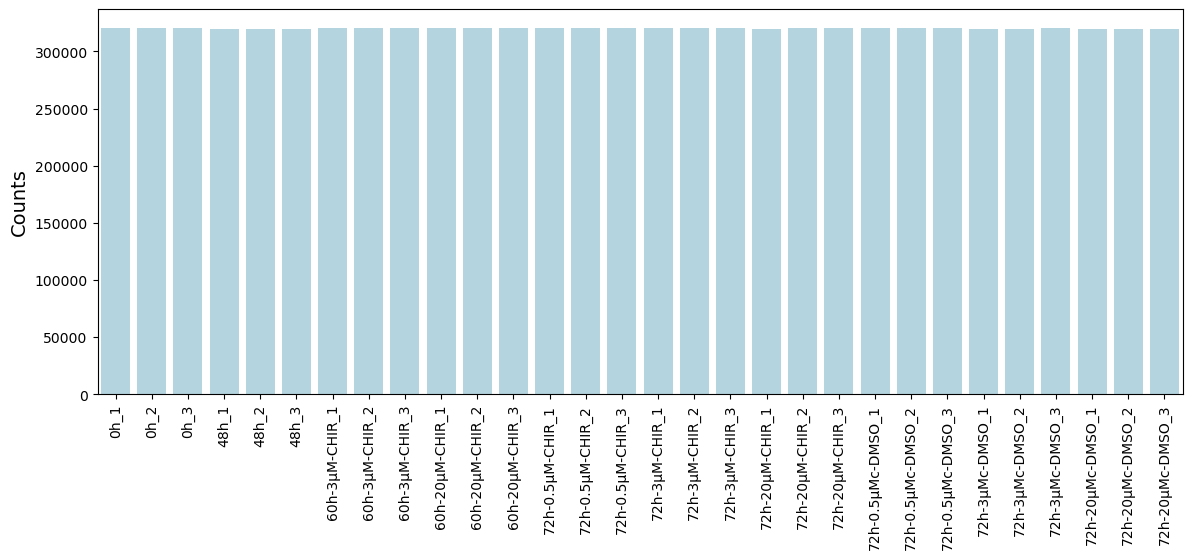

In [ ]:
fig,ax=plt.subplots(1,1,figsize=(14,5))
sns.barplot(df1, x=df1.index, y=df1.sum(axis=1),ax=ax, color='lightblue')

plt.xticks(rotation=90)
plt.ylabel('Counts', size=14)
plt.xlabel('')
# create result folder
plt.savefig(f"{plots_dir}/bulk_library_sizes_sizefactoring.{save_format}")

## Feature selection

We use a simple variance threshold to choose the most varying genes.

Free parameters: **threshold**

In [ ]:
fs = VarianceThreshold(threshold=0.25)
fs.fit(df1.values)
l1 = fs.get_feature_names_out()
l = [int(i[1:]) for i in l1]

print(f"Genes retained: {len(l)}")

Genes retained: 1092


## PCA

<Axes: >

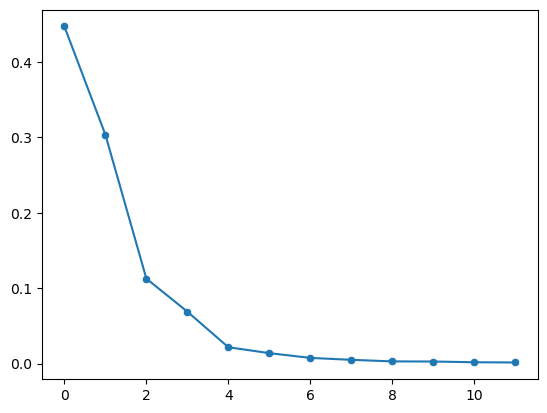

In [ ]:
df1_fs = pd.DataFrame(fs.transform(df1.values),index=df1.index,columns=df1.columns.values[l])
pca = PCA(n_components=12)
pca.fit(df1_fs.values)

sns.lineplot(x=np.arange(0,pca.n_components),y=pca.explained_variance_ratio_)
sns.scatterplot(x=np.arange(0,pca.n_components),y=pca.explained_variance_ratio_)

In [ ]:
names = df1.columns.values[[int(i[1:]) for i in fs.get_feature_names_out()]]
df1_fs = pd.DataFrame(fs.transform(df1.values),index=df1.index,columns=names)
pca = PCA(n_components=min(4,df1.shape[0]-1))
pca.fit(fs.transform(df1.values));

In [ ]:
x = pca.transform(fs.transform(df1.values))

dds.obs['PC1']=x[:,0]
dds.obs['PC2']=x[:,1]

### Representation

Show the PCA components and the Pijuan-Sala projection. The PCA captures time evolution.

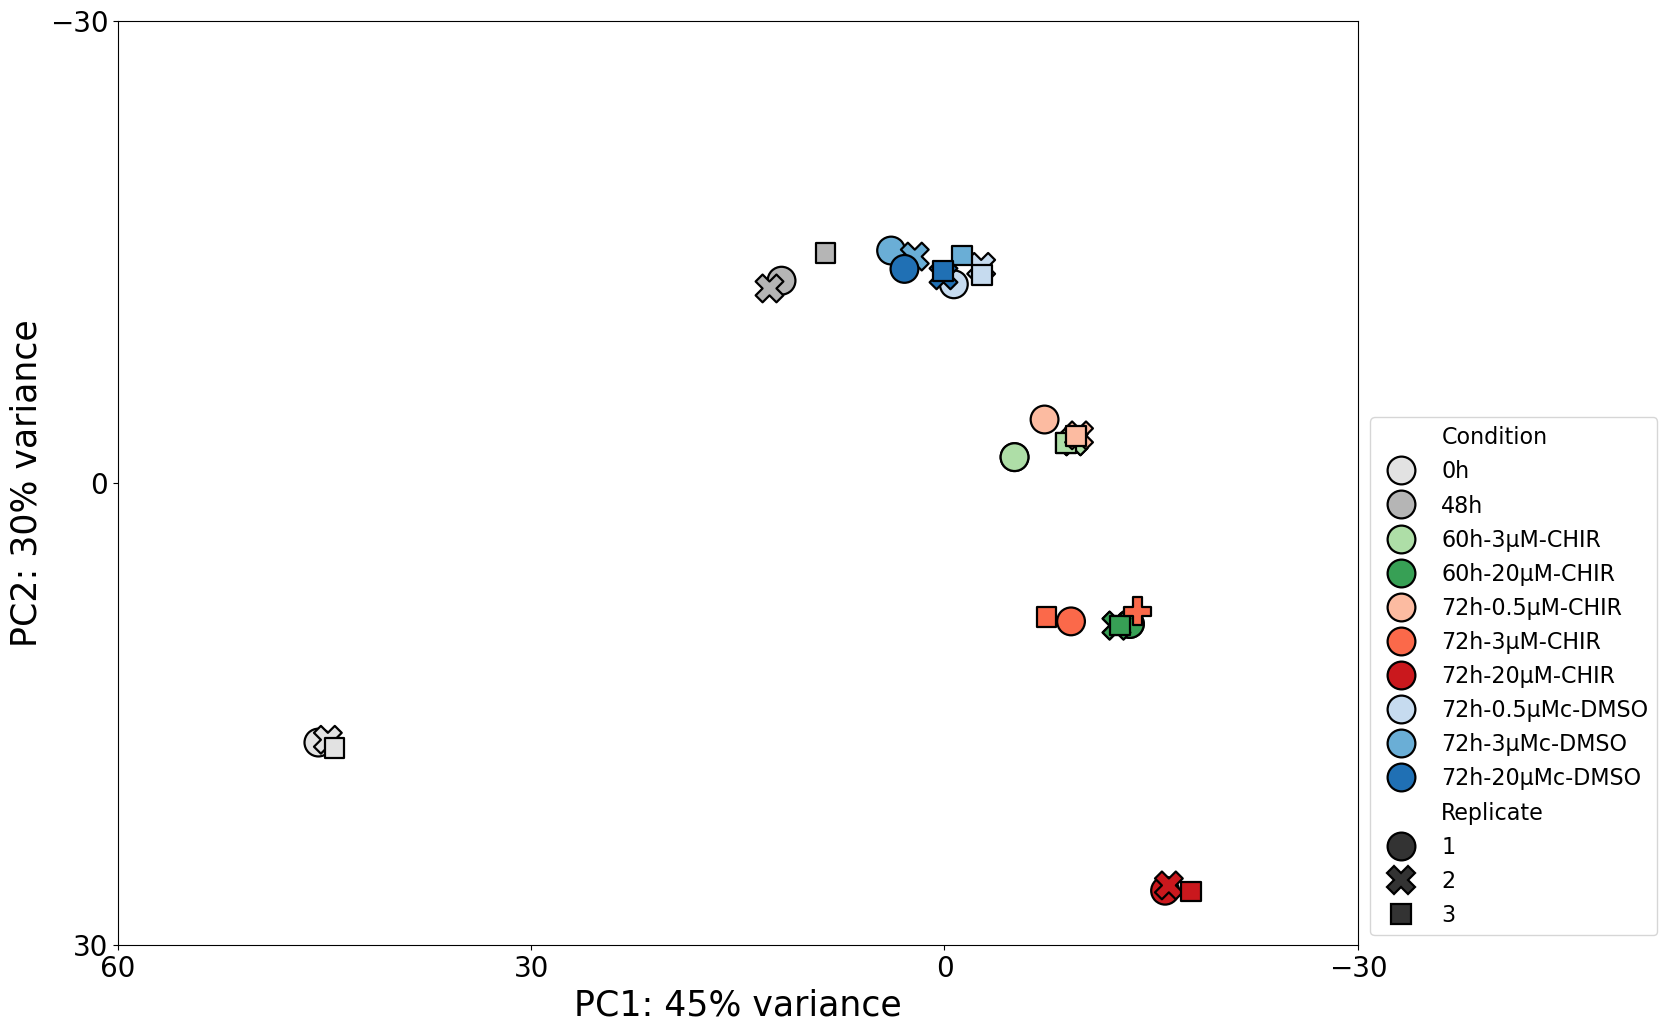

In [ ]:
fig,ax=plt.subplots(1,1,figsize=(16,12))
sns.scatterplot(dds.obs[['0h' in i or '48h' in i for i in dds.obs.index.values]],
                       x='PC1', y='PC2', s=400, edgecolor='black',
                       style='Replicate',hue='Condition', ax=ax, palette='Greys')
sns.scatterplot(dds.obs[['60h' in i  for i in dds.obs.index.values]],
                        x='PC1', y='PC2', s=400, edgecolor='black',
                        style='Replicate', hue='Condition', ax=ax, palette='Greens')
sns.scatterplot(dds.obs[['72h' in i and 'CHIR' in i for i in dds.obs.index.values]],
                        x='PC1', y='PC2', s=400, edgecolor='black', 
                        style='Replicate', hue='Condition', ax=ax, palette='Reds')
sns.scatterplot(dds.obs[['72h' in i and 'DMSO' in i for i in dds.obs.index.values]],
                        x='PC1', y='PC2', s=400, edgecolor='black', 
                        style='Replicate', hue='Condition', ax=ax, palette='Blues')

# axes
plt.xlabel(f'PC1: {int(np.round(pca.explained_variance_ratio_[0]*100,decimals=0))}% variance', fontsize=25)
plt.ylabel(f'PC2: {int(np.round(pca.explained_variance_ratio_[1]*100,decimals=0))}% variance', fontsize=25)

#
ax.set_xticks([-30,0, 30, 60])
plt.xticks(fontsize=20)
ax.set_yticks([-30,0, 30])
plt.yticks(fontsize=20)
ax.invert_xaxis()
ax.invert_yaxis()

# legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
# define order
by_label_ord={}
legend_order=['Condition','0h','48h',
          '60h-3μM-CHIR', '60h-20μM-CHIR',
          '72h-0.5μM-CHIR','72h-3μM-CHIR','72h-20μM-CHIR',
          '72h-0.5μMc-DMSO','72h-3μMc-DMSO','72h-20μMc-DMSO',
          'Replicate', '1','2','3'
         ]
by_label_ord=dict((i,by_label[i]) for i in legend_order)
# increase dot size in legend
# for dot in handles:
#     dot.set_sizes(dot.get_sizes() * 10)
# # add black edge to dots in legend
# for ha in handles:
#     ha.set_edgecolor("black")
#     ha.set_linewidth(2)

plt.legend(by_label_ord.values(), by_label_ord.keys(),prop={'size':16}, loc=(1.01,0.01))

plt.savefig(f"{plots_dir}/bulk_analysis_pca_scatterplot.{save_format}",bbox_inches="tight",transparent=True)

### Loadings

This shows that buttom-left to up-right is capturing changes in genes like (T, Wnt3a, etc.) and up-left to bottom-right capturing expressioon of genes like (Hox-family).

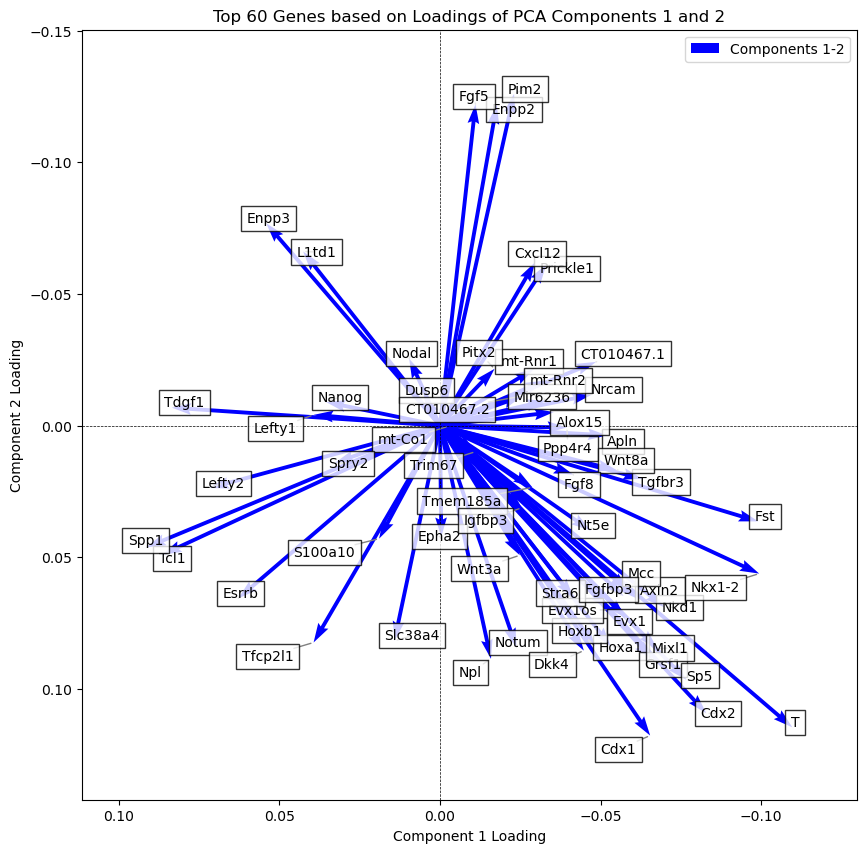

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))

plot_loadings_components(pca,0,1,df1_fs.columns.values,60,ax)

ax.invert_xaxis()
ax.invert_yaxis()

plt.savefig(f"{plots_dir}/bulk_analysis_pca_loadings.{save_format}",bbox_inches="tight",transparent=True)

# Marker Genes 

In [ ]:
# Marker genes
with open(f"{data_dir}/marker_genes.json") as f:
    markers = json.load(f)

print(markers)

{'heatmap_fig1c': ['Pou5f1', 'Nanog', 'Utf1', 'Sox2', 'Otx2', 'Pou3f1', 'Fgf5', 'Nodal', 'Eomes', 'Pitx2', 'Mixl1', 'Wnt3', 'T', 'Cdx1', 'Cdx2', 'Wnt3a', 'Evx1', 'Nkx1-2', 'Epha1', 'Fst', 'Greb1', 'Gdf11', 'Hoxa1', 'Hoxb1', 'Hoxb2', 'Hoxc4', 'Hoxb6', 'Hoxb7', 'Hoxb8', 'Hoxb9'], 'heatmap2': ['Pim2', 'Utf1', 'Pou5f1', 'Nanog', 'Fhf5', 'Otx2', 'Zic5', 'Fgf4', 'Sox2', 'Pou3f1', 'Tcf7l1', 'Wnt3', 'Tdgf1', 'Nodal', 'Foxh1', 'Tet1', 'Eomes', 'Foxa2', 'Zic2', 'Etv1', 'Prickle1', 'Trh', 'Myc', 'Lrp2', 'Fgf15', 'Gas1', 'Eras', 'Smad7', 'Cdh11', 'Tbxt1', 'Fst', 'Mixl1', 'Nkx1-2', 'Pitx2', 'Sp5', 'Sp8', 'Evx1', 'Cdx2', 'Wnt3a', 'Hoxa1', 'Hoxb1'], 'heatmap_af_epi': ['Cdh1', 'Epcam', 'Cdh2', 'Vim', 'Tbx6', 'Msgn1', 'Snai1', 'Mesp1', 'Mesp2', 'Lfng', 'Tcf15'], 'heatmap_dmso': ['Pou3f1', 'Sox1', 'Sox2', 'Otx2', 'Fgf5', 'Pou5f1', 'Nanog', 'Utf1', 'T', 'Cdx2'], 'heatmap_72h': ['Pim2', 'Utf1', 'Pou5f1', 'Nanog', 'Fgf5', 'Otx2', 'Zic5', 'Fgf4', 'Sox2', 'Pou3f1', 'Tcf7l1', 'Wnt3', 'Tdgf1', 'Nodal', 'Foxh1'

### 72h

In [ ]:
# conditions to retain for heatmap
retain = ['48h','72h-0.5μMc-DMSO','72h-3μMc-DMSO','72h-20μMc-DMSO','72h-0.5μM-CHIR','72h-3μM-CHIR','72h-20μM-CHIR']

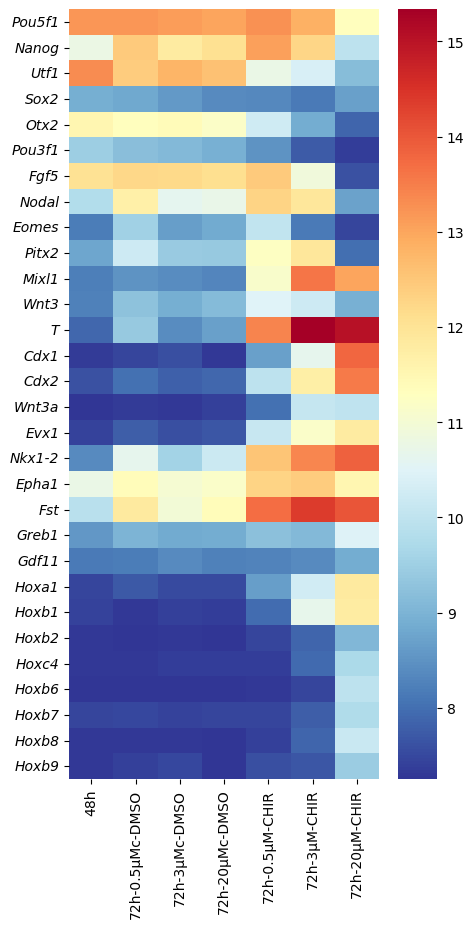

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(5,10))

d_ = df1.loc[:,markers['heatmap_fig1c']].groupby([i[:-2] for i in df_gastruloid_metadata.index]).mean()

g=sns.heatmap(
    d_.loc[retain,:].transpose(),
    cmap="RdYlBu_r"
)
g.set_yticklabels(g.get_yticklabels(), style='italic')

plt.savefig(f"{plots_dir}/bulk_analysis_marker_genes_heatmap.{save_format}",bbox_inches="tight",transparent=True)

# Supplementary figures

### Studying **0h-Epi** and **48h-AF** conditions

**CONSTRUCT DESEQ2 OBJECT AND RUN ALGORITHM**

In [ ]:
#Counts
df_gastruloid = pd.read_csv(f"{data_dir}/wnt_nodal_rnaseq/counts_chir_act_project.csv",index_col=0).T
df_gastruloid = df_gastruloid.loc[:,~df_gastruloid.columns.duplicated()].copy() #Remove potentially duplicated genes names 
df_gastruloid.rename(columns={'T': 'Tbxt'}, inplace=True)

#Metadata
df_gastruloid_metadata = pd.read_csv(f"{data_dir}/wnt_nodal_rnaseq/chir_act_metadata.csv",index_col=0)

In [ ]:
dds_ = DeseqDataSet(
    counts=df_gastruloid.values,
    metadata=df_gastruloid_metadata,
    design_factors="Condition",
    refit_cooks=True
)

# run vst function
dds_.vst(use_design=True)

# df with vst counts
# create df with transformed counts
df1_= pd.DataFrame(data=dds_.layers['vst_counts'],    
             index=dds_.obs.index,    
            columns=df_gastruloid.columns.values)

/home/pau/.local/share/mamba/envs/chir_gastruloids/lib/python3.11/site-packages/pydeseq2/dds.py:257: UserWarning: Some factor levels in the design contain underscores ('_').
                    They will be converted to hyphens ('-').
  self.obsm["design_matrix"] = build_design_matrix(
Fitting size factors...
... done in 0.11 seconds.

Fitting dispersions...
... done in 9.78 seconds.

Fitting dispersion trend curve...
... done in 0.76 seconds.



**FEATURE SELECTION AND PCA**

In [ ]:
## Feature selection
fs_ = VarianceThreshold(threshold=0.25)
fs_.fit(df1_.values)
l1_ = fs_.get_feature_names_out()
l_ = [int(i[1:]) for i in l1_]

print(f"Genes retained: {len(l_)}")

Genes retained: 1389


<Axes: >

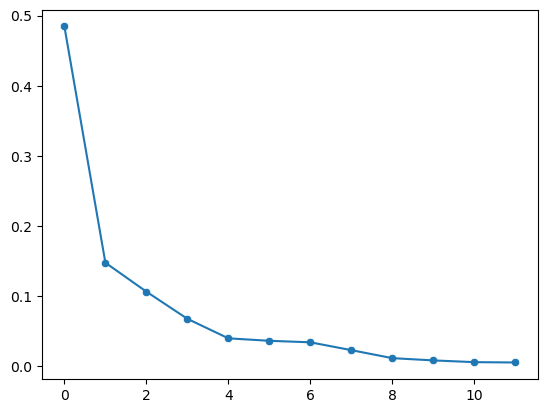

In [ ]:
## PCA
df1_fs_ = pd.DataFrame(fs_.transform(df1_.values),index=df1_.index,columns=df1_.columns.values[l_])
pca_ = PCA(n_components=12)
pca_.fit(df1_fs_.values)

sns.lineplot(x=np.arange(0,pca_.n_components),y=pca_.explained_variance_ratio_)
sns.scatterplot(x=np.arange(0,pca_.n_components),y=pca_.explained_variance_ratio_)


In [ ]:
names_ = df1_.columns.values[[int(i[1:]) for i in fs_.get_feature_names_out()]]
df1_fs_ = pd.DataFrame(fs_.transform(df1_.values),index=df1_.index,columns=names_)
pca_ = PCA(n_components=min(5,df1_.shape[0]-1))
pca_.fit(fs_.transform(df1_.values));
x_ = pca_.transform(fs_.transform(df1_.values))

dds_.obs['PC1']=x_[:,0]
dds_.obs['PC2']=x_[:,1]

## PCA PLOT

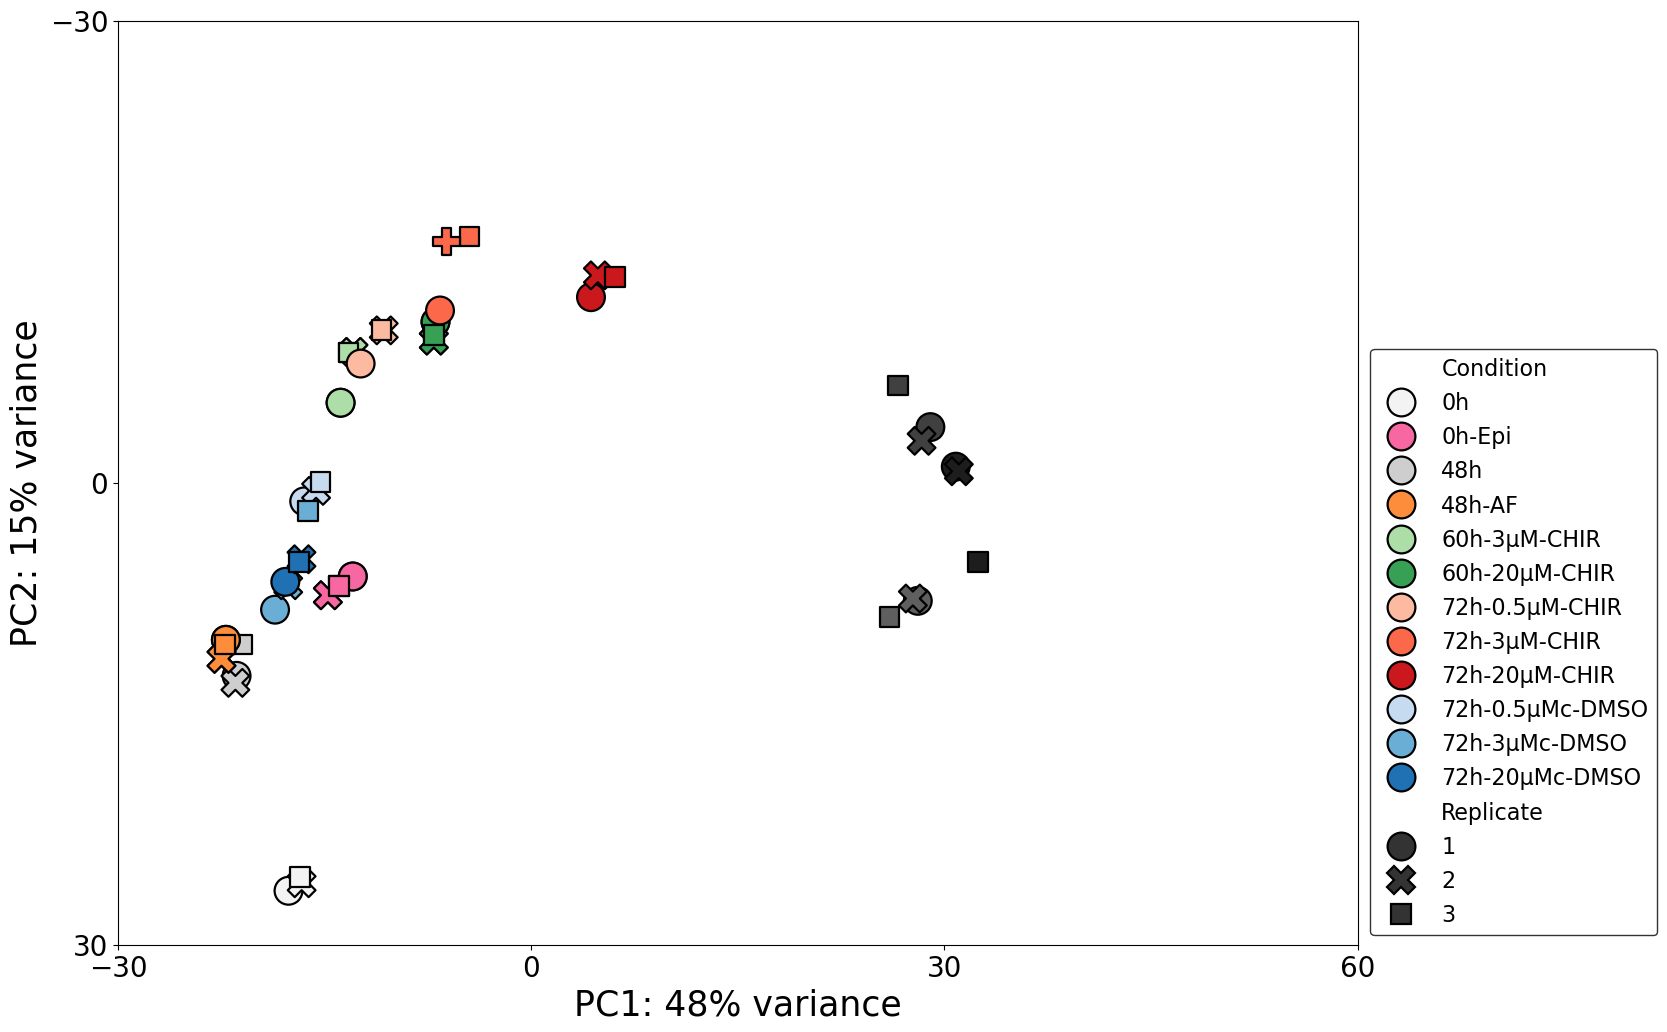

In [ ]:
### Representation
fig,ax=plt.subplots(1,1,figsize=(16,12))
sns.scatterplot(dds_.obs[['0h' in i or '48h' in i for i in dds_.obs.index.values]],
                       x='PC1', y='PC2', s=400, edgecolor='black',
                       style='Replicate',hue='Condition', ax=ax, palette='Greys')
sns.scatterplot(dds_.obs[['0h-Epi' in i for i in dds_.obs.index.values]],
                       x='PC1', y='PC2', s=400, edgecolor='black',
                       style='Replicate',hue='Condition', ax=ax, palette='RdPu')
sns.scatterplot(dds_.obs[['48h-AF' in i for i in dds_.obs.index.values]],
                       x='PC1', y='PC2', s=400, edgecolor='black',
                       style='Replicate',hue='Condition', ax=ax, palette='Oranges')
sns.scatterplot(dds_.obs[['60h' in i  for i in dds_.obs.index.values]],
                        x='PC1', y='PC2', s=400, edgecolor='black',
                        style='Replicate', hue='Condition', ax=ax, palette='Greens')
sns.scatterplot(dds_.obs[['72h' in i and 'CHIR' in i for i in dds_.obs.index.values]],
                        x='PC1', y='PC2', s=400, edgecolor='black', 
                        style='Replicate', hue='Condition', ax=ax, palette='Reds')
sns.scatterplot(dds_.obs[['72h' in i and 'DMSO' in i for i in dds_.obs.index.values]],
                        x='PC1', y='PC2', s=400, edgecolor='black', 
                        style='Replicate', hue='Condition', ax=ax, palette='Blues')

# axes
plt.xlabel(f'PC1: {int(np.round(pca_.explained_variance_ratio_[0]*100,decimals=0))}% variance', fontsize=25)
plt.ylabel(f'PC2: {int(np.round(pca_.explained_variance_ratio_[1]*100,decimals=0))}% variance', fontsize=25)

#
ax.set_xticks([-30,0, 30, 60])
plt.xticks(fontsize=20)
ax.set_yticks([-30,0, 30])
plt.yticks(fontsize=20)
#ax.invert_xaxis()
ax.invert_yaxis()

### legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
# define order
by_label_ord={}
legend_order=['Condition','0h','0h-Epi','48h','48h-AF',
          '60h-3μM-CHIR', '60h-20μM-CHIR',
          '72h-0.5μM-CHIR','72h-3μM-CHIR','72h-20μM-CHIR',
          '72h-0.5μMc-DMSO','72h-3μMc-DMSO','72h-20μMc-DMSO',
          'Replicate', '1','2','3'
         ]
by_label_ord=dict((i,by_label[i]) for i in legend_order)
# # increase dot size in legend
# for dot in handles:
#     dot.set_sizes(dot.get_sizes() * 10)
# # add black edge to dots in legend
# for ha in handles:
#     ha.set_edgecolor("black")
#     ha.set_linewidth(2)

plt.legend(by_label_ord.values(), by_label_ord.keys(),prop={'size':16}, loc=(1.01,0.01), markerscale=1.0, edgecolor="black")

plt.savefig(f"{plots_dir}/bulk_analysis_pca_scatterplot_with_af_epi.{save_format}",bbox_inches="tight",transparent=True)

## Marker Genes for Epi and AF

## CHIR vs DMSO

In [ ]:
retain=['48h_1','48h_2','48h_3',
           '72h-3μMc-DMSO_1','72h-3μMc-DMSO_2','72h-3μMc-DMSO_3',  
            '72h-20μMc-DMSO_1','72h-20μMc-DMSO_2','72h-20μMc-DMSO_3',
           '72h-3μM-CHIR_1','72h-3μM-CHIR_2','72h-3μM-CHIR_3', 
           '72h-20μM-CHIR_1','72h-20μM-CHIR_2','72h-20μM-CHIR_3']

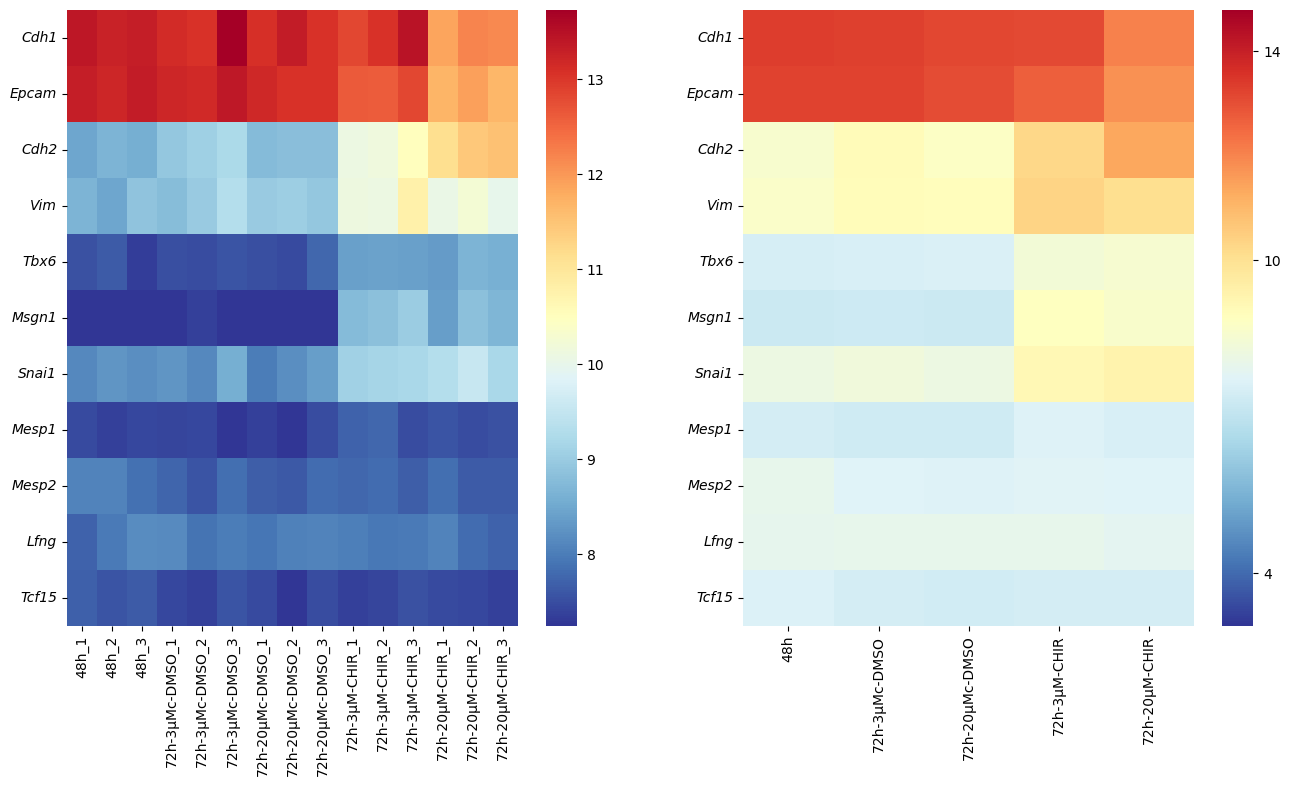

In [ ]:
# retain samples of interest
d_s = df1.loc[:,markers['heatmap_af_epi']]
d_s_mean = df1.loc[:,markers['heatmap_af_epi']].groupby([i[:-2] for i in df1.index]).mean()

fig,ax=plt.subplots(1,2, figsize=(16,8))
sns.heatmap(
    d_s.loc[retain].transpose(),
    cmap="RdYlBu_r",
    ax=ax[0]
)
ax[0].set(xlabel=None)
ax[0].tick_params('y', labelrotation=0)
ax[0].set_yticklabels(ax[0].get_yticklabels(),style='italic')
hm2=sns.heatmap(
    d_s_mean.loc[['48h','72h-3μMc-DMSO','72h-20μMc-DMSO','72h-3μM-CHIR', '72h-20μM-CHIR']].transpose(),
    cmap="RdYlBu_r",
    ax=ax[1],  vmin=3, vmax=14.8
)
# Custom colorbar ticks for heatmap 2 (ax[1])
colorbar2 = hm2.collections[0].colorbar
colorbar2.set_ticks([4, 10, 14])
colorbar2.set_ticklabels(['4', '10', '14'])
ax[1].tick_params('y', labelrotation=0)
ax[1].set_yticklabels(ax[1].get_yticklabels(),style='italic')

plt.savefig(f"{plots_dir}/bulk_analysis_heatmap_chir_dmso.{save_format}",bbox_inches="tight",transparent=True)

# CHIR3 vs CHIR20

In [ ]:
retain=['72h-3μM-CHIR_1','72h-3μM-CHIR_2','72h-3μM-CHIR_3', 
        '72h-20μM-CHIR_1','72h-20μM-CHIR_2','72h-20μM-CHIR_3']

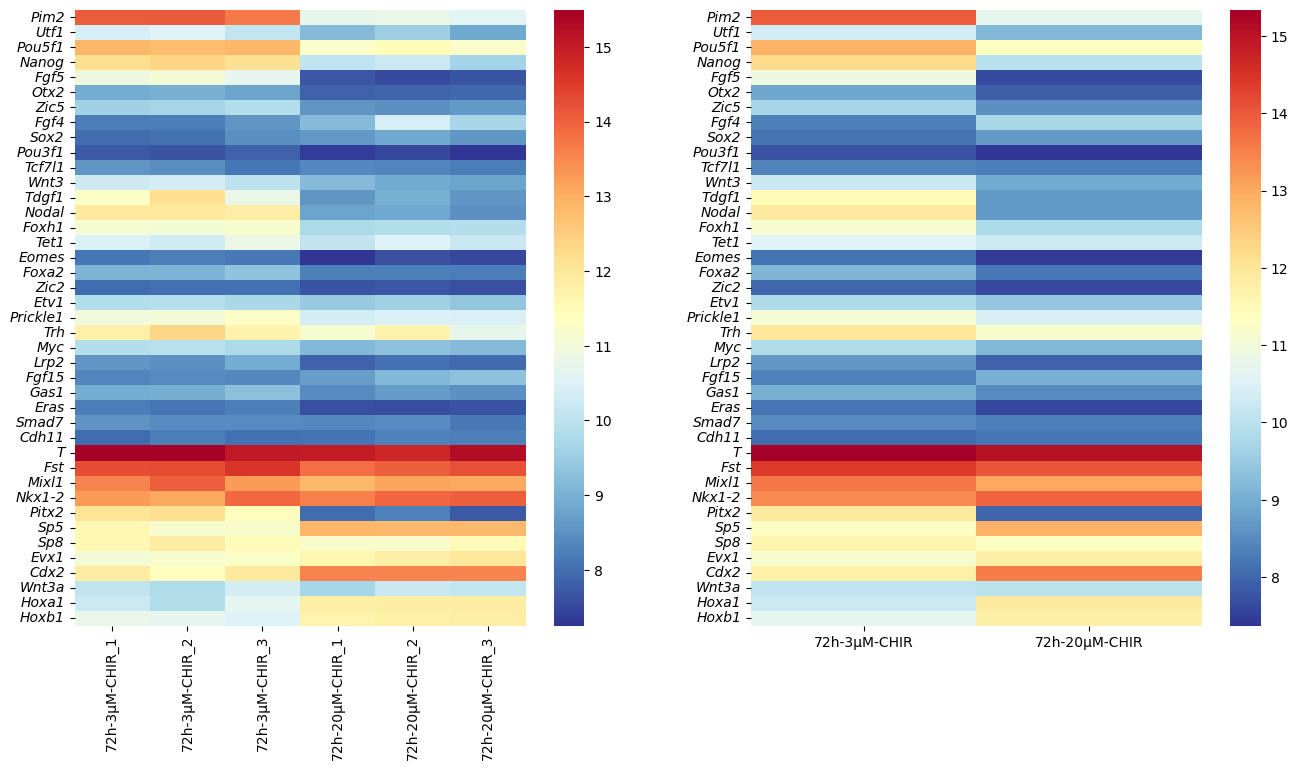

In [ ]:
# retain samples of interest
d_s = df1.loc[[i in retain for i in df1.index],markers['heatmap_72h']]
d_s_mean = d_s.groupby([i[:-2] for i in d_s.index]).mean()

fig,ax=plt.subplots(1,2, figsize=(16,8))
sns.heatmap(
    d_s.loc[retain].transpose(),
    cmap="RdYlBu_r", 
    ax=ax[0],
)
ax[0].set(xlabel=None)
ax[0].tick_params('y', labelrotation=0)
ax[0].set_yticklabels(ax[0].get_yticklabels(), style='italic')
sns.heatmap(
    d_s_mean.loc[['72h-3μM-CHIR','72h-20μM-CHIR']].transpose(),
    cmap="RdYlBu_r",
    ax=ax[1]
)
ax[1].tick_params('y', labelrotation=0)
ax[1].set_yticklabels(ax[1].get_yticklabels(), style='italic')

plt.savefig(f"{plots_dir}/bulk_analysis_heatmap_chir3_vs_chir20.{save_format}",bbox_inches="tight",transparent=True)

# Chir 60h and 72h

In [ ]:
retain=['48h_1','48h_2','48h_3',
        '60h-3μM-CHIR_2', '60h-3μM-CHIR_3', '60h-20μM-CHIR_1', 
           '72h-3μM-CHIR_1','72h-3μM-CHIR_2','72h-3μM-CHIR_3', 
'72h-3μMc-DMSO_1','72h-3μMc-DMSO_2','72h-3μMc-DMSO_3']

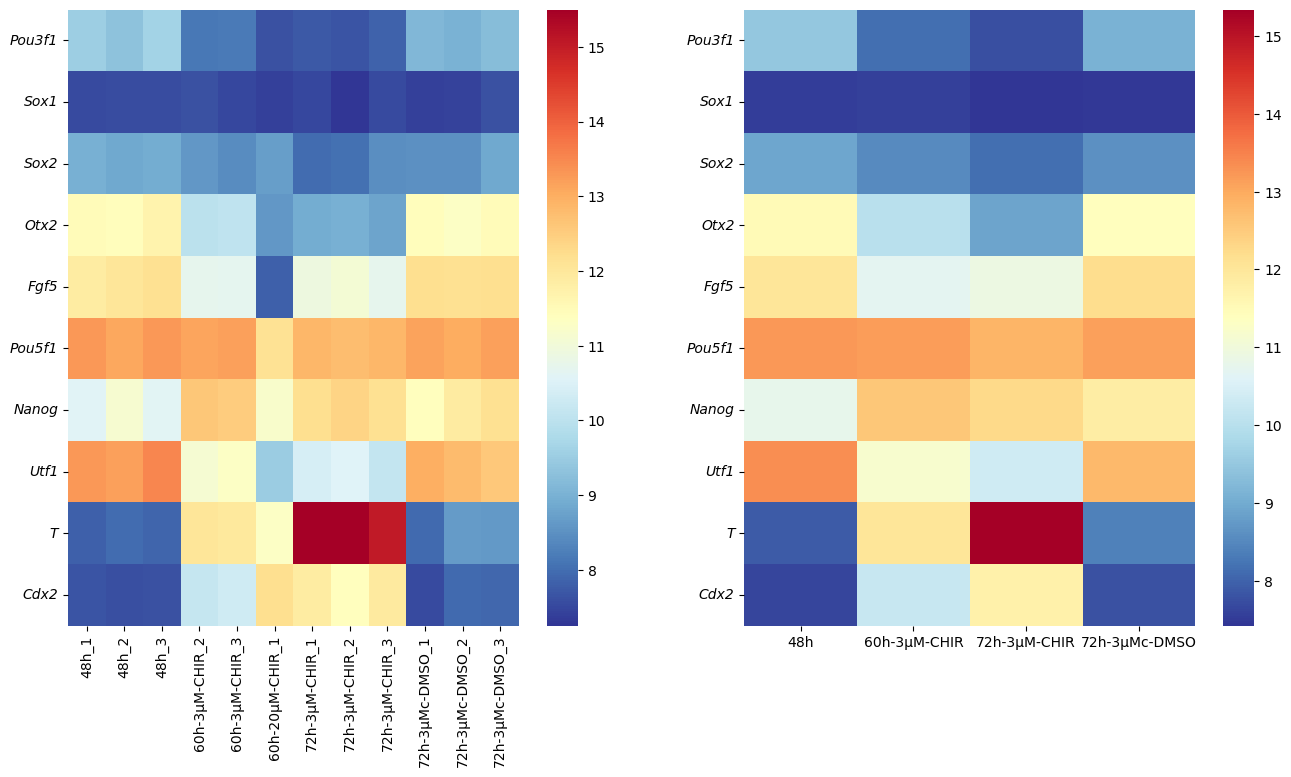

In [ ]:
# retain samples of interest
d_s = df1.loc[[i in retain for i in df1.index],markers['heatmap_dmso']]
d_s_mean = d_s.groupby([i[:-2] for i in d_s.index]).mean()

fig,ax=plt.subplots(1,2, figsize=(16,8))
sns.heatmap(
    d_s.loc[retain].transpose(),
    cmap="RdYlBu_r", 
    ax=ax[0],
)
ax[0].set(xlabel=None)
ax[0].tick_params('y', labelrotation=0)
ax[0].set_yticklabels(ax[0].get_yticklabels(), style='italic')

sns.heatmap(
    d_s_mean.loc[['48h','60h-3μM-CHIR','72h-3μM-CHIR','72h-3μMc-DMSO']].transpose(),
    cmap="RdYlBu_r",
    ax=ax[1]
)
ax[1].tick_params('y', labelrotation=0)
ax[1].set_yticklabels(ax[1].get_yticklabels(), style='italic')

plt.savefig(f"{plots_dir}/bulk_analysis_heatmap_48h_60hchir_72h.{save_format}",bbox_inches="tight",transparent=True)

# ACT VS CHIR

In [ ]:
retain=['48h_1','48h_2','48h_3',
        '72h-0.5μM-CHIR_1','72h-0.5μM-CHIR_2', '72h-0.5μM-CHIR_3',
          '72h-3μM-CHIR_1','72h-3μM-CHIR_2','72h-3μM-CHIR_3','72h-3μM-CHIR_5', 
          '72h-3μMc-DMSO_1','72h-3μMc-DMSO_2','72h-3μMc-DMSO_3',
         '72h-low-ActA_1','72h-low-ActA_2','72h-low-ActA_3',
          '72h-high-ActA_1','72h-high-ActA_2','72h-high-ActA_3',
          '96h-3μM-CHIR_1','96h-3μM-CHIR_2','96h-3μM-CHIR_3',
          '96h-low-ActA_1','96h-low-ActA_2','96h-low-ActA_3',
          '96h-high-ActA_1','96h-high-ActA_2','96h-high-ActA_3',
           '120h-3μM-CHIR_1','120h-3μM-CHIR_2','120h-3μM-CHIR_3',
           '120h-low-ActA_1','120h-low-ActA_2','120h-low-ActA_3',
           '120h-high-ActA_1','120h-high-ActA_2','120h-high-ActA_3',
           '144h-low-ActA_1','144h-low-ActA_2','144h-low-ActA_3',
          '144h-high-ActA_1','144h-high-ActA_2','144h-high-ActA_3'
          ] 

In [ ]:
# retain=['48h_1','48h_2','48h_3',
#           '72h-3μMc-DMSO_1','72h-3μMc-DMSO_2','72h-3μMc-DMSO_3',
#         '72h-0.5μM-CHIR_1','72h-0.5μM-CHIR_2', '72h-0.5μM-CHIR_3',
#           '72h-3μM-CHIR_1','72h-3μM-CHIR_2','72h-3μM-CHIR_3','72h-3μM-CHIR_5', 
#           '72h-high-ActA_1','72h-high-ActA_2','72h-high-ActA_3',
#           '96h-3μM-CHIR_1','96h-3μM-CHIR_2','96h-3μM-CHIR_3',
#           '96h-high-ActA_1','96h-high-ActA_2','96h-high-ActA_3',
#           '120h-3μM-CHIR_1','120h-3μM-CHIR_2','120h-3μM-CHIR_3',
#           '120h-high-ActA_1','120h-high-ActA_2','120h-high-ActA_3',
#           ] 

In [ ]:
df_gastruloid = df_gastruloid[[i in retain for i in df_gastruloid.index]]
df_gastruloid_metadata=df_gastruloid_metadata[[i in retain for i in df_gastruloid_metadata.index]]

NameError: name 'retain' is not defined

# Normalized table

In [ ]:
# run deseq2_norm fucntion
dds_norm=deseq2_norm(df_gastruloid)

dds_norm[0].T.to_csv(f"{data_dir}/normalized_counts_act_chir.csv")

# DDS object

In [ ]:
dds = DeseqDataSet(
    counts=df_gastruloid.values,
    metadata=df_gastruloid_metadata,
    design_factors="Condition",
    refit_cooks=True
)
dds.var_names=df_gastruloid.columns

/home/pau/.local/share/mamba/envs/chir_gastruloids/lib/python3.11/site-packages/pydeseq2/dds.py:257: UserWarning: Some factor levels in the design contain underscores ('_').
                    They will be converted to hyphens ('-').
  self.obsm["design_matrix"] = build_design_matrix(


# VST

In [ ]:
dds.vst(use_design=True)
# create df with transformed counts
df1= pd.DataFrame(data=dds.layers['vst_counts'],    
             index=dds.obs.index,    
            columns=df_gastruloid.columns.values)


Fitting size factors...
... done in 0.07 seconds.

Fitting dispersions...
... done in 7.36 seconds.

Fitting dispersion trend curve...
... done in 0.64 seconds.



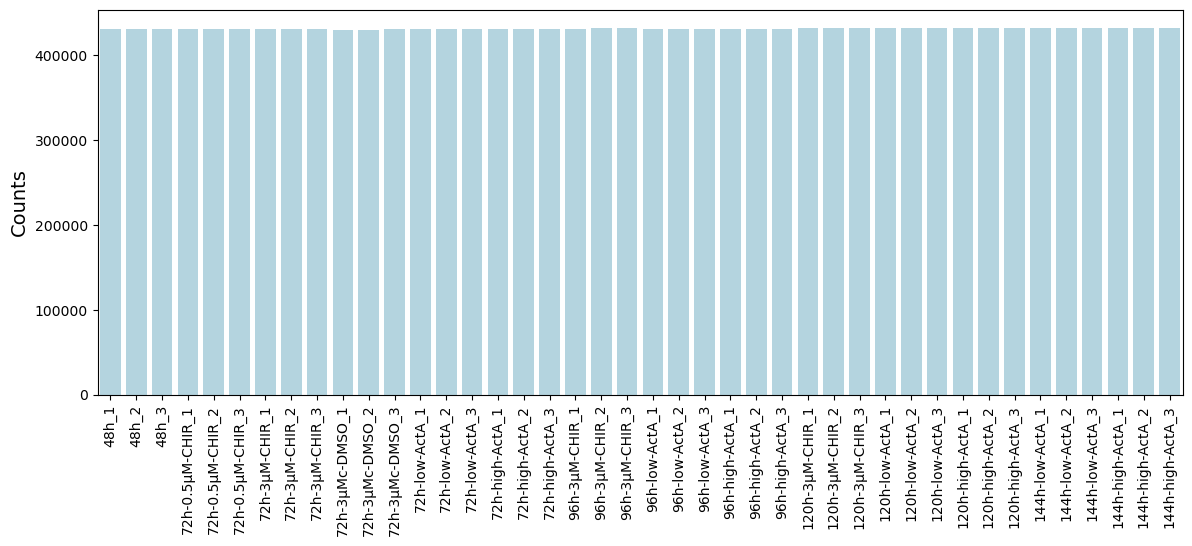

In [ ]:
fig,ax=plt.subplots(1,1,figsize=(14,5))
sns.barplot(df1, x=df1.index, y=df1.sum(axis=1),ax=ax, color='lightblue')

plt.xticks(rotation=90)
plt.ylabel('Counts', size=14)
plt.xlabel('')
# create result folder
plt.savefig(f"{plots_dir}/bulk_library_sizes_sizefactoring_act_vs_chir.{save_format}")

In [ ]:
fs = VarianceThreshold(threshold=0.35)
fs.fit(df1.values)
l1 = fs.get_feature_names_out()
l = [int(i[1:]) for i in l1]

print(f"Genes retained: {len(l)}")

Genes retained: 1033


<Axes: >

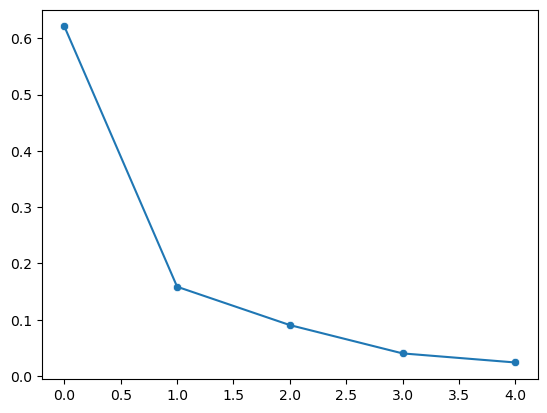

In [ ]:

df1_fs = pd.DataFrame(fs.transform(df1.values),index=df1.index,columns=df1.columns.values[l])
pca = PCA(n_components=5)
pca.fit(df1_fs.values)

sns.lineplot(x=np.arange(0,pca.n_components),y=pca.explained_variance_ratio_)
sns.scatterplot(x=np.arange(0,pca.n_components),y=pca.explained_variance_ratio_)


In [ ]:
names = df1.columns.values[[int(i[1:]) for i in fs.get_feature_names_out()]]
df1_fs = pd.DataFrame(fs.transform(df1.values),index=df1.index,columns=names)
pca = PCA(n_components=min(4,df1.shape[0]-1))
pca.fit(fs.transform(df1.values));

In [ ]:
x = pca.transform(fs.transform(df1.values))

dds.obs['PC1']=x[:,0]
dds.obs['PC2']=x[:,1]

# PCA plot

# 1st

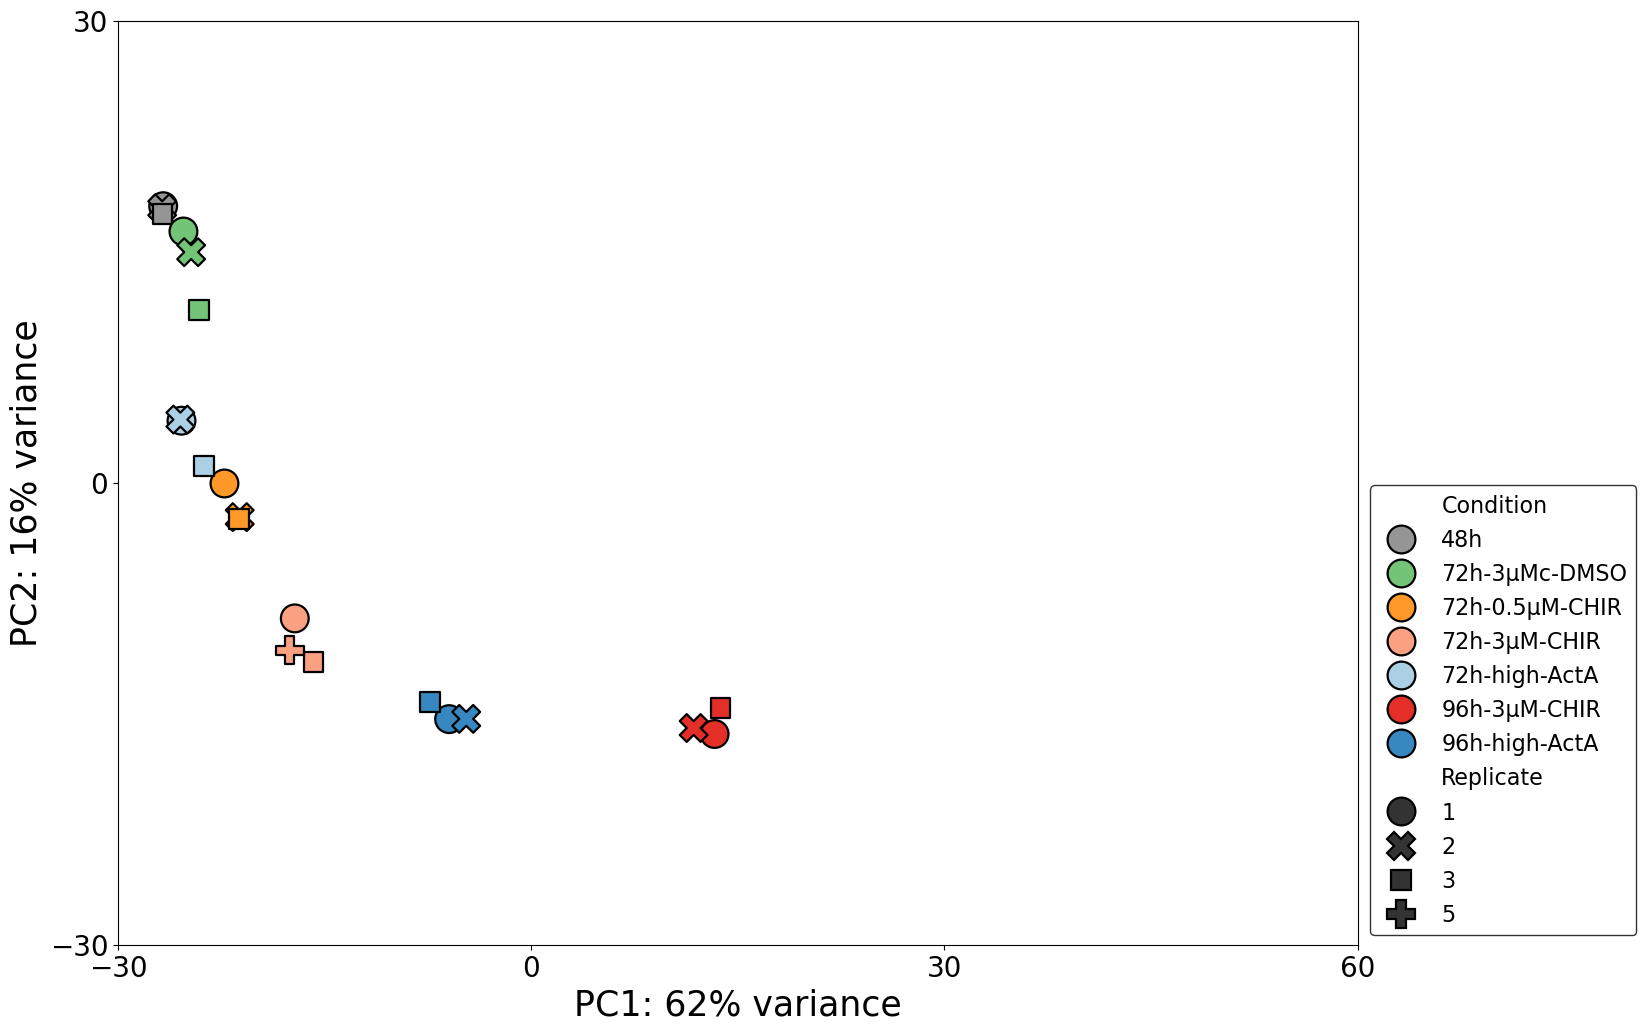

In [ ]:
### Representation
fig,ax=plt.subplots(1,1,figsize=(16,12))
sns.scatterplot(dds.obs[['48h' in i for i in dds.obs.index.values]],
                       x='PC1', y='PC2', s=400, edgecolor='black',
                       style='Replicate',hue='Condition', ax=ax, palette='Greys')
sns.scatterplot(dds.obs[[('72h-3μM-CHIR' in i) or ('96h-3μM-CHIR' in i) for i in dds.obs.index.values]],
                     x='PC1', y='PC2', s=400, edgecolor='black', 
                        style='Replicate', hue='Condition', ax=ax, palette='Reds')
sns.scatterplot(dds.obs[[('0.5μM-CHIR' in i) for i in dds.obs.index.values]],
                     x='PC1', y='PC2', s=400, edgecolor='black', 
                        style='Replicate', hue='Condition', ax=ax, palette='YlOrBr')
sns.scatterplot(dds.obs[['DMSO' in i for i in dds.obs.index.values]],
                     x='PC1', y='PC2', s=400, edgecolor='black', 
                        style='Replicate', hue='Condition', ax=ax, palette='Greens')
# sns.scatterplot(dds.obs[['low-ActA' in i for i in dds.obs.index.values]],
#                         x='PC1', y='PC2', s=400, edgecolor='black', 
#                         style='Replicate', hue='Condition', ax=ax, palette='Greens')
sns.scatterplot(dds.obs[[('72h-high-ActA' in i) or ('96h-high-ActA' in i) for i in dds.obs.index.values]],
                        x='PC1', y='PC2', s=400, edgecolor='black', 
                        style='Replicate', hue='Condition', ax=ax, palette='Blues')
# axes
plt.xlabel(f'PC1: {int(np.round(pca.explained_variance_ratio_[0]*100,decimals=0))}% variance', fontsize=25)
plt.ylabel(f'PC2: {int(np.round(pca.explained_variance_ratio_[1]*100,decimals=0))}% variance', fontsize=25)
#
ax.set_xticks([-30,0, 30, 60])
plt.xticks(fontsize=20)
ax.set_yticks([-30,0, 30])
plt.yticks(fontsize=20)
#ax.invert_xaxis()
#ax.invert_yaxis()

### legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
# define order
by_label_ord={}
legend_order=['Condition','48h','72h-3μMc-DMSO',
              '72h-0.5μM-CHIR','72h-3μM-CHIR', '72h-high-ActA',
          '96h-3μM-CHIR','96h-high-ActA',
          'Replicate', '1','2','3','5'
         ]
# legend_order=['Condition','48h','72h-0.5μM-CHIR'
#              '72h-3μM-CHIR','72h-low-ActA', '72h-high-ActA',
#           '96h-3μM-CHIR','96h-low-ActA','96h-high-ActA',
#           '120h-3μM-CHIR','120h-low-ActA','120h-high-ActA',
#           '144h-low-ActA', '144h-high-ActA',
#           'Replicate', '1','2','3'
#          ]
by_label_ord=dict((i,by_label[i]) for i in legend_order)
# # increase dot size in legend
# for dot in handles:
#     dot.set_sizes(dot.get_sizes() * 10)
# # add black edge to dots in legend
# for ha in handles:
#     ha.set_edgecolor("black")
#     ha.set_linewidth(2)

plt.legend(by_label_ord.values(), by_label_ord.keys(),prop={'size':16}, loc=(1.01,0.01), markerscale=1.0, edgecolor="black")

plt.savefig(f"{plots_dir}/bulk_analysis_pca_scatterplot_act_high_vs_chir_72h_96h.{save_format}",bbox_inches="tight",transparent=True)

# 1st: Loadings

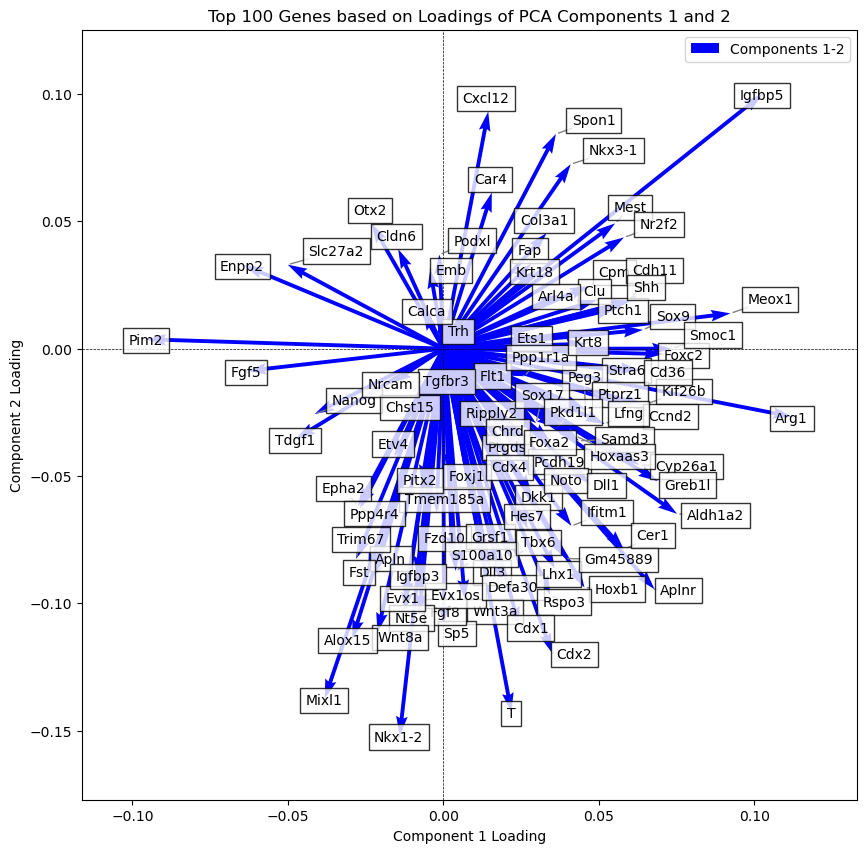

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))

plot_loadings_components(pca,0,1,df1_fs.columns.values,100,ax)

#ax.invert_yaxis()

plt.savefig(f"{plots_dir}/bulk_analysis_pca_100loadings_act_vs_chir_72h_96h.{save_format}",bbox_inches="tight",transparent=True)

# 2nd 

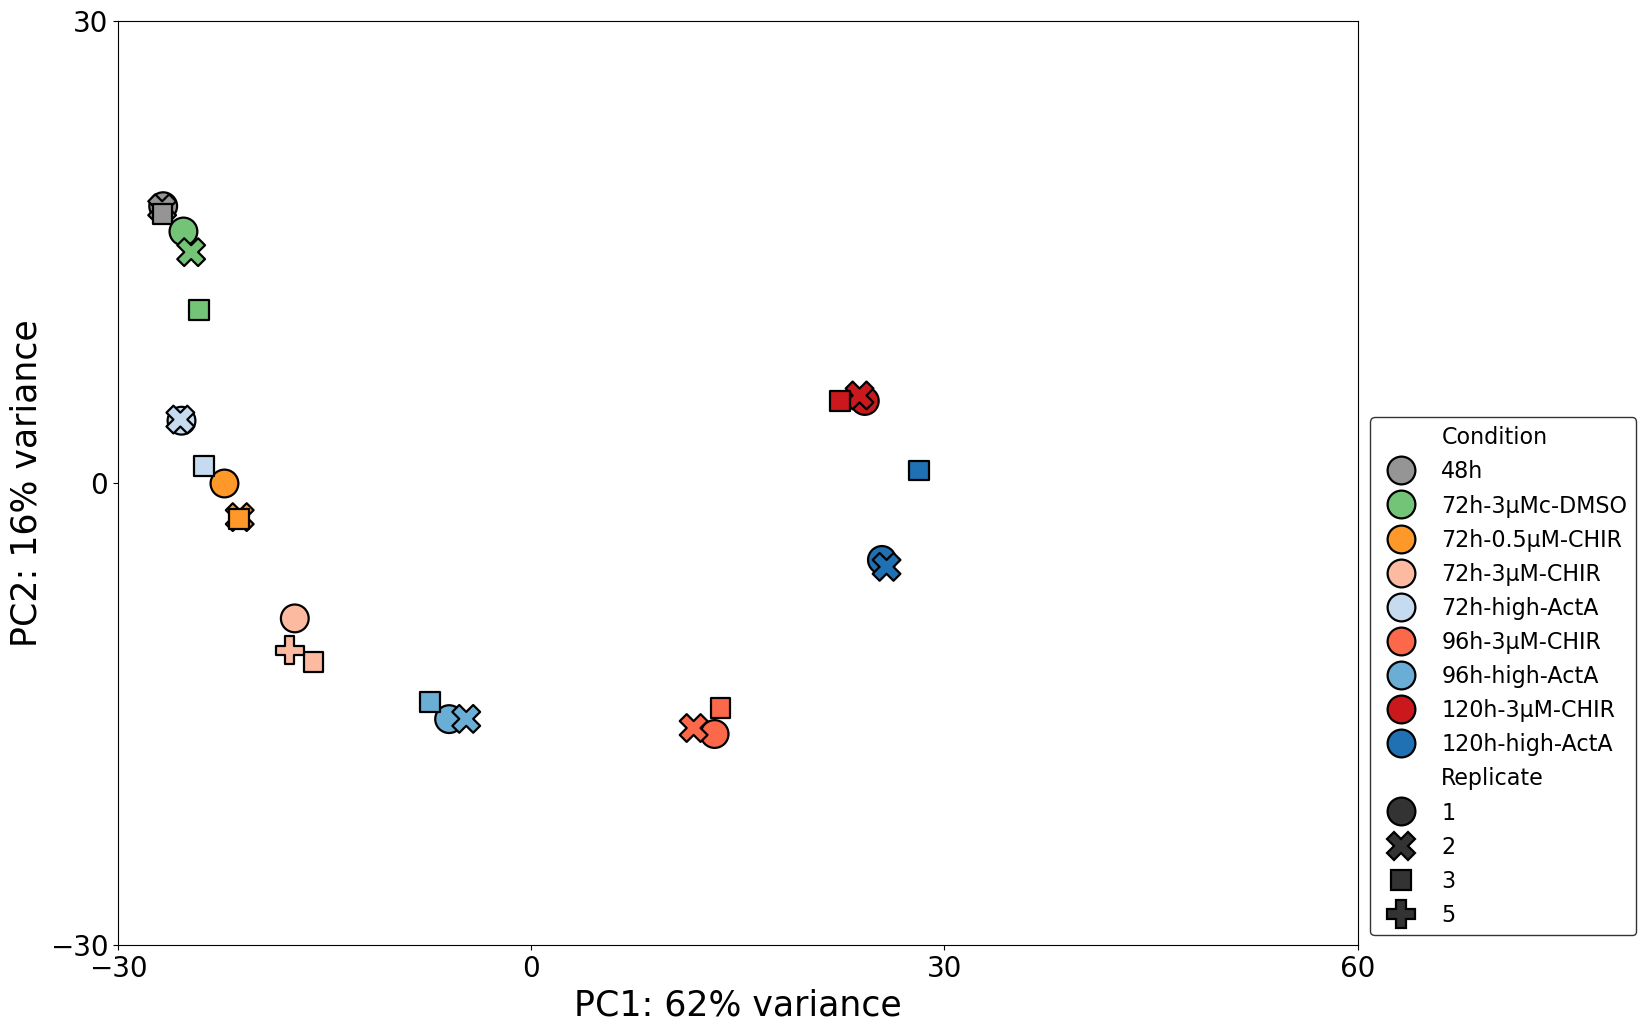

In [ ]:
### Representation
fig,ax=plt.subplots(1,1,figsize=(16,12))
sns.scatterplot(dds.obs[['48h' in i for i in dds.obs.index.values]],
                       x='PC1', y='PC2', s=400, edgecolor='black',
                       style='Replicate',hue='Condition', ax=ax, palette='Greys')
sns.scatterplot(dds.obs[[('72h-3μM-CHIR' in i) or ('96h-3μM-CHIR' in i) or ('120h-3μM-CHIR' in i) for i in dds.obs.index.values]],
                     x='PC1', y='PC2', s=400, edgecolor='black', 
                        style='Replicate', hue='Condition', ax=ax, palette='Reds')
sns.scatterplot(dds.obs[[('0.5μM-CHIR' in i) for i in dds.obs.index.values]],
                     x='PC1', y='PC2', s=400, edgecolor='black', 
                        style='Replicate', hue='Condition', ax=ax, palette='YlOrBr')
sns.scatterplot(dds.obs[['DMSO' in i for i in dds.obs.index.values]],
                     x='PC1', y='PC2', s=400, edgecolor='black', 
                        style='Replicate', hue='Condition', ax=ax, palette='Greens')
# sns.scatterplot(dds.obs[['low-ActA' in i for i in dds.obs.index.values]],
#                         x='PC1', y='PC2', s=400, edgecolor='black', 
#                         style='Replicate', hue='Condition', ax=ax, palette='Greens')
sns.scatterplot(dds.obs[[('72h-high-ActA' in i) or ('96h-high-ActA' in i) or ('120h-high-ActA' in i) for i in dds.obs.index.values]],
                        x='PC1', y='PC2', s=400, edgecolor='black', 
                        style='Replicate', hue='Condition', ax=ax, palette='Blues')
# axes
plt.xlabel(f'PC1: {int(np.round(pca.explained_variance_ratio_[0]*100,decimals=0))}% variance', fontsize=25)
plt.ylabel(f'PC2: {int(np.round(pca.explained_variance_ratio_[1]*100,decimals=0))}% variance', fontsize=25)
#
ax.set_xticks([-30,0, 30, 60])
plt.xticks(fontsize=20)
ax.set_yticks([-30,0, 30])
plt.yticks(fontsize=20)
#ax.invert_xaxis()
#ax.invert_yaxis()

### legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
# define order
by_label_ord={}
legend_order=['Condition','48h','72h-3μMc-DMSO',
              '72h-0.5μM-CHIR','72h-3μM-CHIR', '72h-high-ActA',
          '96h-3μM-CHIR','96h-high-ActA', 
          '120h-3μM-CHIR','120h-high-ActA', 
          'Replicate', '1','2','3','5'
         ]
# legend_order=['Condition','48h','72h-0.5μM-CHIR'
#              '72h-3μM-CHIR','72h-low-ActA', '72h-high-ActA',
#           '96h-3μM-CHIR','96h-low-ActA','96h-high-ActA',
#           '120h-3μM-CHIR','120h-low-ActA','120h-high-ActA',
#           '144h-low-ActA', '144h-high-ActA',
#           'Replicate', '1','2','3'
#          ]
by_label_ord=dict((i,by_label[i]) for i in legend_order)
# # increase dot size in legend
# for dot in handles:
#     dot.set_sizes(dot.get_sizes() * 10)
# # add black edge to dots in legend
# for ha in handles:
#     ha.set_edgecolor("black")
#     ha.set_linewidth(2)

plt.legend(by_label_ord.values(), by_label_ord.keys(),prop={'size':16}, loc=(1.01,0.01), markerscale=1.0, edgecolor="black")

plt.savefig(f"{plots_dir}/bulk_analysis_pca_scatterplot_act_high_vs_chir_72h_96h_120h.{save_format}",bbox_inches="tight",transparent=True)

# 2nd: Loadings

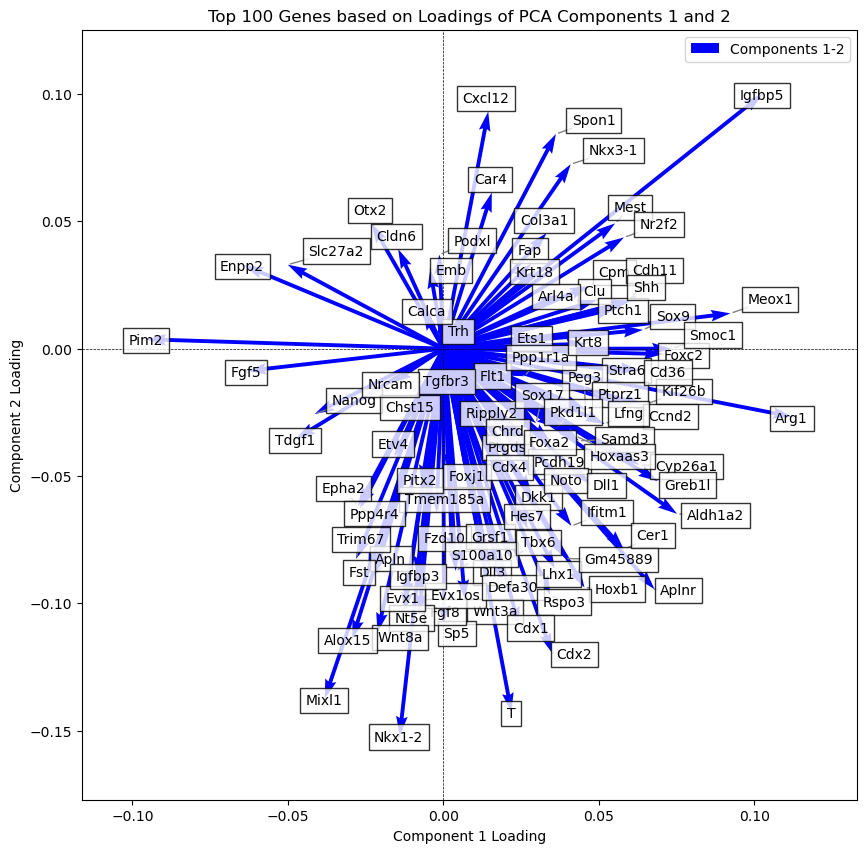

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))

plot_loadings_components(pca,0,1,df1_fs.columns.values,100,ax)

#ax.invert_yaxis()

plt.savefig(f"{plots_dir}/bulk_analysis_pca_100loadings_act_vs_chir_72h_96h_120h.{save_format}",bbox_inches="tight",transparent=True)

# 3rd: CHIR3 VS high-ActA

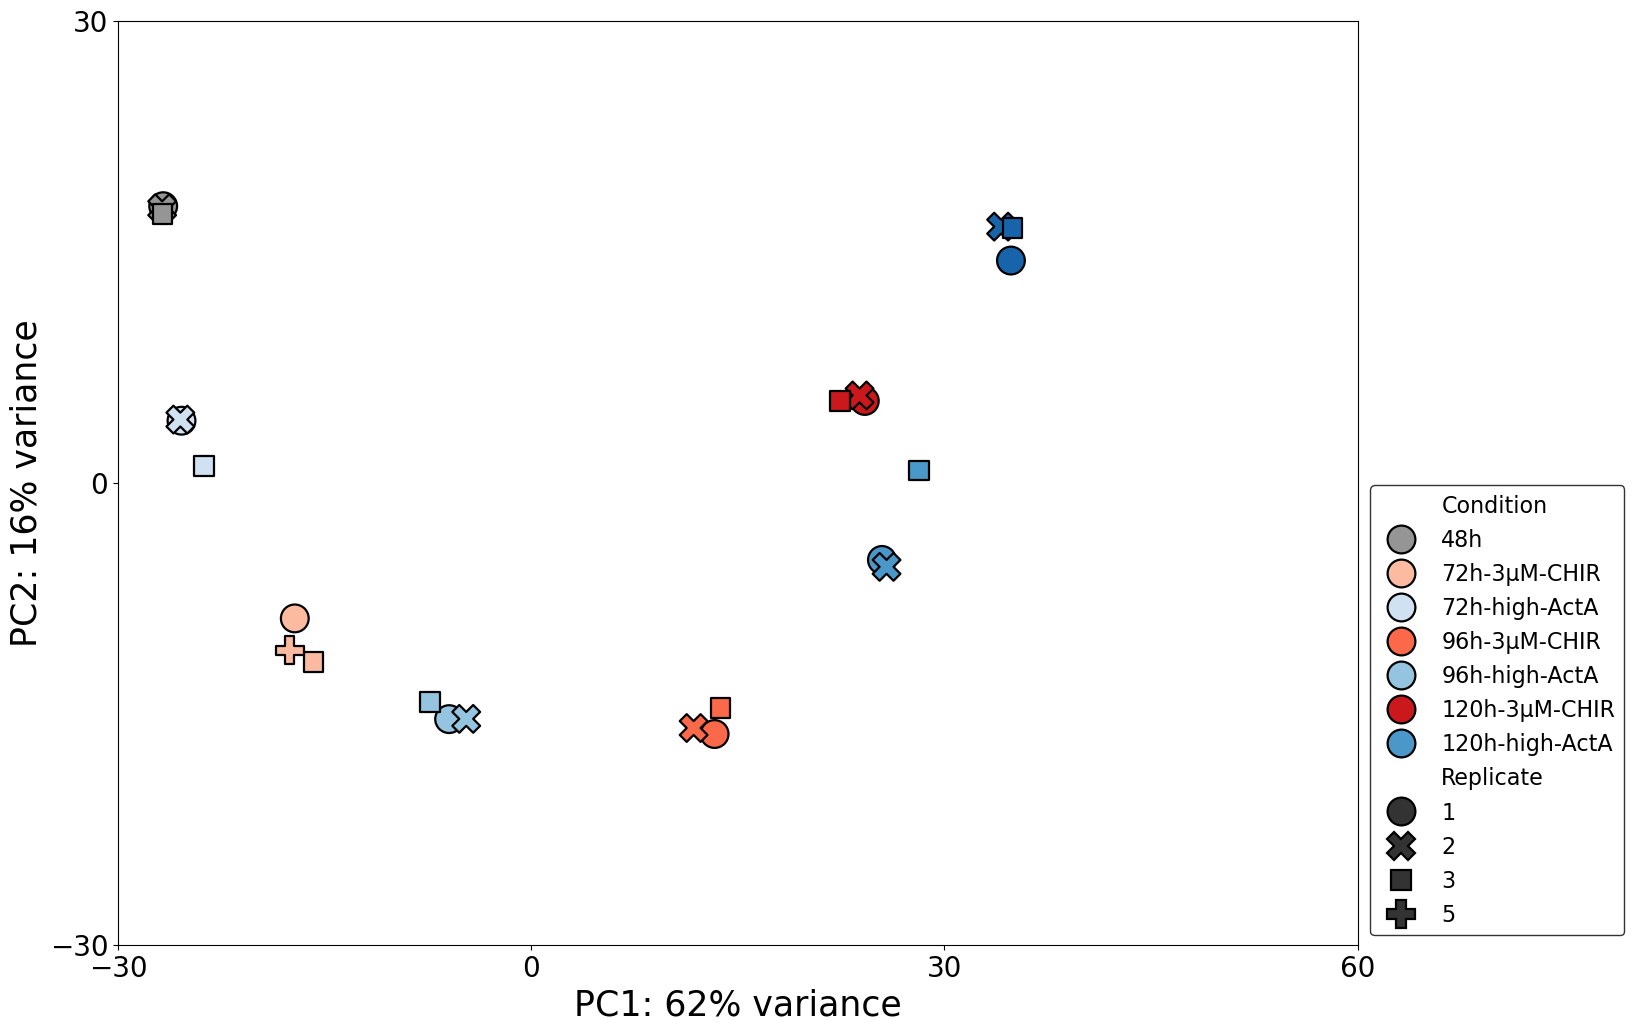

In [ ]:
### Representation
fig,ax=plt.subplots(1,1,figsize=(16,12))
sns.scatterplot(dds.obs[['48h' in i for i in dds.obs.index.values]],
                       x='PC1', y='PC2', s=400, edgecolor='black',
                       style='Replicate',hue='Condition', ax=ax, palette='Greys')
sns.scatterplot(dds.obs[[('3μM-CHIR' in i) for i in dds.obs.index.values]],
                     x='PC1', y='PC2', s=400, edgecolor='black', 
                        style='Replicate', hue='Condition', ax=ax, palette='Reds')
# sns.scatterplot(dds.obs[['low-ActA' in i for i in dds.obs.index.values]],
#                         x='PC1', y='PC2', s=400, edgecolor='black', 
#                         style='Replicate', hue='Condition', ax=ax, palette='Greens')
sns.scatterplot(dds.obs[['high-ActA' in i for i in dds.obs.index.values]],
                        x='PC1', y='PC2', s=400, edgecolor='black', 
                        style='Replicate', hue='Condition', ax=ax, palette='Blues')
# axes
plt.xlabel(f'PC1: {int(np.round(pca.explained_variance_ratio_[0]*100,decimals=0))}% variance', fontsize=25)
plt.ylabel(f'PC2: {int(np.round(pca.explained_variance_ratio_[1]*100,decimals=0))}% variance', fontsize=25)
#
ax.set_xticks([-30,0, 30, 60])
plt.xticks(fontsize=20)
ax.set_yticks([-30,0, 30])
plt.yticks(fontsize=20)
#ax.invert_xaxis()
#ax.invert_yaxis()

### legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
# define order
by_label_ord={}
legend_order=['Condition','48h','72h-3μM-CHIR', '72h-high-ActA',
          '96h-3μM-CHIR','96h-high-ActA','120h-3μM-CHIR','120h-high-ActA',
          'Replicate', '1','2','3','5'
         ]
# legend_order=['Condition','48h','72h-0.5μM-CHIR'
#              '72h-3μM-CHIR','72h-low-ActA', '72h-high-ActA',
#           '96h-3μM-CHIR','96h-low-ActA','96h-high-ActA',
#           '120h-3μM-CHIR','120h-low-ActA','120h-high-ActA',
#           '144h-low-ActA', '144h-high-ActA',
#           'Replicate', '1','2','3'
#          ]
by_label_ord=dict((i,by_label[i]) for i in legend_order)
# # increase dot size in legend
# for dot in handles:
#     dot.set_sizes(dot.get_sizes() * 10)
# # add black edge to dots in legend
# for ha in handles:
#     ha.set_edgecolor("black")
#     ha.set_linewidth(2)

plt.legend(by_label_ord.values(), by_label_ord.keys(),prop={'size':16}, loc=(1.01,0.01), markerscale=1.0, edgecolor="black")

plt.savefig(f"{plots_dir}/bulk_analysis_pca_scatterplot_act_high_vs_chir3_72h-120h.{save_format}",bbox_inches="tight",transparent=True)

# 3rd: Loadings

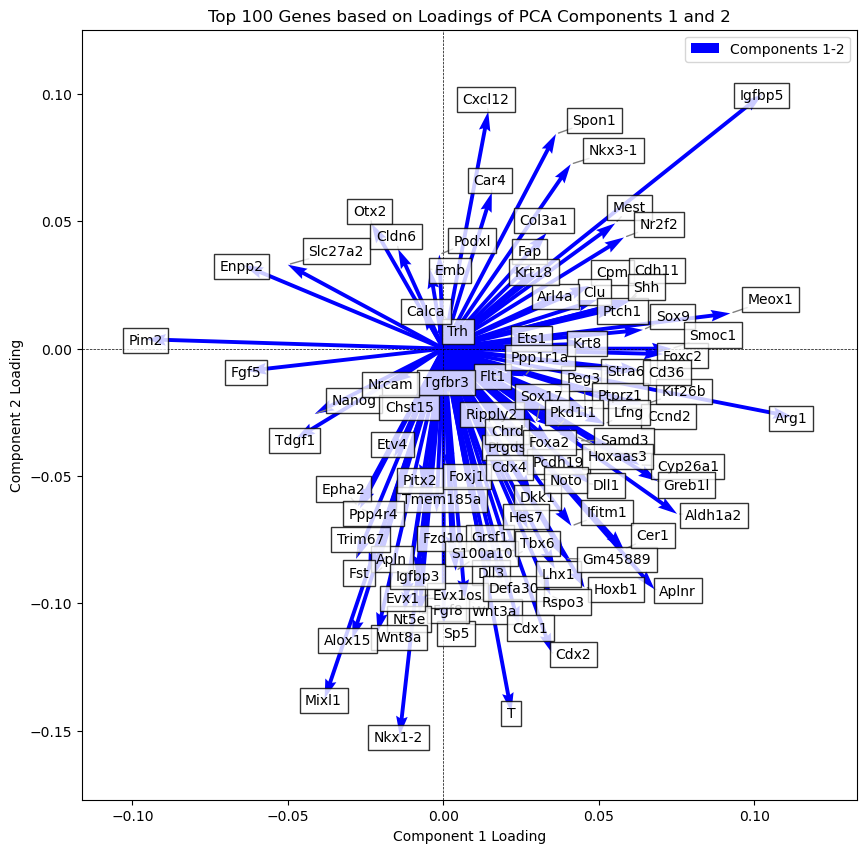

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))

plot_loadings_components(pca,0,1,df1_fs.columns.values,100,ax)

#ax.invert_yaxis()

plt.savefig(f"{plots_dir}/bulk_analysis_pca_100loadings_act_vs_chir3_72h-120h.{save_format}",bbox_inches="tight",transparent=True)

# PAIR-WISE COMPARISON

In [ ]:
#Counts
df_gastruloid = pd.read_csv(f"{data_dir}/wnt_nodal_rnaseq/counts_chir_act_project.csv",index_col=0).T
df_gastruloid = df_gastruloid.loc[:,~df_gastruloid.columns.duplicated()].copy() #Remove potentially duplicated genes names 
df_gastruloid.rename(columns={'T': 'Tbxt'}, inplace=True)

#Metadata
df_gastruloid_metadata = pd.read_csv(f"{data_dir}/wnt_nodal_rnaseq/chir_act_metadata.csv",index_col=0)

In [ ]:
dds = DeseqDataSet(
    counts=df_gastruloid.values,
    metadata=df_gastruloid_metadata,
    design_factors="Condition",
    refit_cooks=False
)
dds.var_names=df_gastruloid.columns

dds.deseq2()


/home/pau/.local/share/mamba/envs/chir_gastruloids/lib/python3.11/site-packages/pydeseq2/dds.py:257: UserWarning: Some factor levels in the design contain underscores ('_').
                    They will be converted to hyphens ('-').
  self.obsm["design_matrix"] = build_design_matrix(
Fitting size factors...
... done in 0.10 seconds.

Fitting dispersions...
... done in 5.68 seconds.

Fitting dispersion trend curve...
... done in 0.49 seconds.

Fitting MAP dispersions...
... done in 8.38 seconds.

Fitting LFCs...
... done in 7.73 seconds.



In [ ]:
LFC_THRES=0.5
PADJ_THRES=0.1

In [ ]:
contrasts=[('Condition','72h-low-ActA','48h'),
           ('Condition','72h-high-ActA','48h'),
           ('Condition','72h-low-ActA','72h-3μM-CHIR'),
            ('Condition','72h-0.5μM-CHIR','72h-3μM-CHIR'),
            ('Condition','72h-high-ActA','72h-0.5μM-CHIR'),
            ('Condition', '72h-high-ActA','72h-3μMc-DMSO'),
           ('Condition','72h-high-ActA','72h-3μM-CHIR'),
           ('Condition', '72h-low-ActA', '72h-high-ActA'),
           ('Condition','72h-high-ActA','96h-high-ActA'),
           ('Condition','96h-high-ActA','96h-3μM-CHIR'),
           ('Condition','96h-high-ActA','96h-low-ActA'),
           ('Condition','120h-high-ActA','96h-high-ActA'),
           ('Condition','120h-high-ActA','120h-low-ActA'),
           ('Condition','120h-high-ActA','120h-3μM-CHIR'),
           ('Condition','144h-high-ActA','120h-high-ActA'),
           ('Condition','144h-high-ActA','144h-low-ActA')]


# Rank genes and compute DEGs

In [ ]:
os.makedirs(f'{results_dir}/pair-wise',exist_ok=True)

In [ ]:
for c in contrasts:
    # set up statistical on constrast
    stat_res=DeseqStats(dds, contrast=c,quiet=True)
    # run t-test
    stat_res.summary()
    
    # results df, sorted by lfc
    res=stat_res.results_df
    res.index=dds.var.index #reset genenames, they get lost
    res=res.sort_values(by='log2FoldChange', ascending=False)
    res['-log10P']=-np.log10(res.pvalue)
    res=res[res.baseMean>100]

    #DEGs subsetting
    degs=res[(abs(res['log2FoldChange'])>LFC_THRES) & (res['pvalue']<PADJ_THRES)]

    # save tables
    res.to_csv(f"{results_dir}/pair-wise/ranked_{c[1]}_vs_{c[2]}.csv")
    degs.to_csv(f"{results_dir}/pair-wise/degs_{c[1]}_vs_{c[2]}.csv")

Log2 fold change & Wald test p-value: Condition 72h-low-ActA vs 48h
                  baseMean  log2FoldChange     lfcSE      stat        pvalue  \
Gene                                                                           
4933401J01Rik     0.000000             NaN       NaN       NaN           NaN   
Gm26206           0.000000             NaN       NaN       NaN           NaN   
Xkr4             32.517998        2.498884  0.476370  5.245682  1.557056e-07   
Gm18956           0.219724        1.455919  9.868800  0.147527  8.827157e-01   
Gm37180           3.310302        2.098873  1.291218  1.625499  1.040563e-01   
...                    ...             ...       ...       ...           ...   
AC124606.1        0.000000             NaN       NaN       NaN           NaN   
AC133095.2        0.523527       -1.863556  4.995432 -0.373052  7.091098e-01   
AC133095.1        0.000000             NaN       NaN       NaN           NaN   
AC234645.1        0.000000             NaN       NaN

/home/pau/.local/share/mamba/envs/chir_gastruloids/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Log2 fold change & Wald test p-value: Condition 96h-high-ActA vs 96h-low-ActA
                  baseMean  log2FoldChange     lfcSE      stat    pvalue  \
Gene                                                                       
4933401J01Rik     0.000000             NaN       NaN       NaN       NaN   
Gm26206           0.000000             NaN       NaN       NaN       NaN   
Xkr4             32.517998       -0.080825  0.404464 -0.199832  0.841612   
Gm18956           0.219724       -0.028683  9.634548 -0.002977  0.997625   
Gm37180           3.310302       -1.119856  1.186414 -0.943899  0.345221   
...                    ...             ...       ...       ...       ...   
AC124606.1        0.000000             NaN       NaN       NaN       NaN   
AC133095.2        0.523527       -0.283819  5.493251 -0.051667  0.958794   
AC133095.1        0.000000             NaN       NaN       NaN       NaN   
AC234645.1        0.000000             NaN       NaN       NaN       NaN   
AC149090.1

## Volcano plots

In [ ]:
os.makedirs(f'{results_dir}/volcano', exist_ok=True)

In [ ]:
dds.obs['Condition'].unique()

array(['0h', '0h-Epi', '48h', '48h-AF', '60h-3μM-CHIR', '60h-20μM-CHIR',
       '72h-0.5μM-CHIR', '72h-3μM-CHIR', '72h-20μM-CHIR',
       '72h-0.5μMc-DMSO', '72h-3μMc-DMSO', '72h-20μMc-DMSO',
       '72h-low-ActA', '72h-high-ActA', '96h-3μM-CHIR', '96h-low-ActA',
       '96h-high-ActA', '120h-3μM-CHIR', '120h-low-ActA',
       '120h-high-ActA', '144h-low-ActA', '144h-high-ActA'], dtype=object)

### *72h high vs low ActA*

In [ ]:
stat_res=DeseqStats(dds, contrast=('Condition', '72h-high-ActA', '72h-low-ActA'),quiet=True)
# run t-test
stat_res.summary()

# results df, sorted by lfc
res_df=stat_res.results_df
# plot volcano
plot_volcano(res_df, lfc_threshold = 2, pvalue_threshold= 0.05, basemean_filter= 10, gene_labels=True, dot_size=50,
                palette1 = ['red', 'green', 'blue', 'lightgrey'], palette2 = ['purple'], title=f'ActA_high_vs_low_72h_lfc2',
                get_degs=True, save_format = 'svg', save_dir=f'{results_dir}/volcano')
plt.close()

Log2 fold change & Wald test p-value: Condition 72h-high-ActA vs 72h-low-ActA
                  baseMean  log2FoldChange     lfcSE      stat    pvalue  \
Gene                                                                       
4933401J01Rik     0.000000             NaN       NaN       NaN       NaN   
Gm26206           0.000000             NaN       NaN       NaN       NaN   
Xkr4             32.517998        0.064560  0.421564  0.153144  0.878285   
Gm18956           0.219724       -0.759078  9.868045 -0.076923  0.938685   
Gm37180           3.310302       -1.063964  1.246632 -0.853471  0.393398   
...                    ...             ...       ...       ...       ...   
AC124606.1        0.000000             NaN       NaN       NaN       NaN   
AC133095.2        0.523527       -0.759091  5.326132 -0.142522  0.886668   
AC133095.1        0.000000             NaN       NaN       NaN       NaN   
AC234645.1        0.000000             NaN       NaN       NaN       NaN   
AC149090.1

### *72h 0.5_CHIR vs 72h 20h_CHIR*

In [ ]:
genes = ["Hoxc5","Hoxb6","Hoxb5","Hoxb8","Hoxd9","Hoxb4","Hoxc4","Hoxa3","Noto","Cdx1","Cdx4","Hoxb1","Hoxb2","Hoxd4",
         "Hoxa5","Hoxb9","Aldh1a2","Hoxb3","Hoxc6","Hoxa1","Cdx2","Hoxa2","Dkk1","Wnt3a","Hoxd1","Mnx1","Fgf17","Cdh2",
         "Hoxd3","Mixl1","Evx1","Fgf5","Eomes","Pou3f1","Pitx2","Gsc","Otx2","Nodal","Tdgf1","Lefty1","Zic2","Nanog",
         "Lefty2","Zic5","Wnt3","Utf1","Pou5f1","Wnt11"]


In [ ]:
stat_res=DeseqStats(dds, contrast=('Condition', '72h-20μM-CHIR', '72h-0.5μM-CHIR'),quiet=True)
# run t-test
stat_res.summary()

# results df, sorted by lfc
res_df=stat_res.results_df
# plot volcano
plot_volcano(res_df, lfc_threshold = 2, pvalue_threshold= 0.05, basemean_filter= 10, gene_labels=True, dot_size=50, markers = genes,
                palette1 = ['red', 'green', 'blue', 'lightgrey'], palette2 = ['purple'], title=f'0.5CHIR_vs_20CHIR_72h_lfc_2',
                get_degs=True, save_format = 'svg', save_dir=f'{results_dir}/volcano')
plt.close()

Log2 fold change & Wald test p-value: Condition 72h-20μM-CHIR vs 72h-0.5μM-CHIR
                  baseMean  log2FoldChange     lfcSE      stat    pvalue  \
Gene                                                                       
4933401J01Rik     0.000000             NaN       NaN       NaN       NaN   
Gm26206           0.000000             NaN       NaN       NaN       NaN   
Xkr4             32.517998       -1.537106  0.437640 -3.512264  0.000444   
Gm18956           0.219724       -0.389526  9.964768 -0.039090  0.968818   
Gm37180           3.310302        0.382572  1.073081  0.356518  0.721453   
...                    ...             ...       ...       ...       ...   
AC124606.1        0.000000             NaN       NaN       NaN       NaN   
AC133095.2        0.523527        0.572258  5.329589  0.107374  0.914492   
AC133095.1        0.000000             NaN       NaN       NaN       NaN   
AC234645.1        0.000000             NaN       NaN       NaN       NaN   
AC149090

### *72h 3_CHIR vs 72h high Act*

In [ ]:
genes = ["Cer1","Eomes","Tal2","Dbx2","Otx2","Fgf4","Zic2","Pou3f1","Six1","Cyp26a1","Cdh11","Fgf15","Fgf5","Tdgf1",
         "Lrp2","Wnt11","Utf1","Trh","Wnt3a","Hoxc5","Hoxa3","Hoxb1","Cdx1","Dkk4","Hoxa1","Hoxb2","Cdx2","Hoxb4",
         "Hoxb5","Cdx4","Hoxc4","Hoxa2","Tbxt","Mixl1","Nkx1-2","Evx1","Hoxd1"
]


In [ ]:
stat_res=DeseqStats(dds, contrast=('Condition', '72h-high-ActA', '72h-3μM-CHIR'),quiet=True)
# run t-test
stat_res.summary()

# results df, sorted by lfc
res_df=stat_res.results_df
# plot volcano
plot_volcano(res_df, lfc_threshold = 1.5, pvalue_threshold= 0.05, basemean_filter= 10, gene_labels=True, dot_size=50,markers = genes,
                palette1 = ['red', 'green', 'blue', 'lightgrey'], palette2 = ['purple'], title=f'high_act_vs_3_CHIR_72h_lfc_1.5',
                get_degs=True, save_format = 'svg', save_dir=f'{results_dir}/volcano')
plt.close()

Log2 fold change & Wald test p-value: Condition 72h-high-ActA vs 72h-3μM-CHIR
                  baseMean  log2FoldChange     lfcSE      stat    pvalue  \
Gene                                                                       
4933401J01Rik     0.000000             NaN       NaN       NaN       NaN   
Gm26206           0.000000             NaN       NaN       NaN       NaN   
Xkr4             32.517998       -0.356229  0.416294 -0.855715  0.392156   
Gm18956           0.219724        0.257773  9.970022  0.025855  0.979373   
Gm37180           3.310302       -0.109811  1.307798 -0.083966  0.933083   
...                    ...             ...       ...       ...       ...   
AC124606.1        0.000000             NaN       NaN       NaN       NaN   
AC133095.2        0.523527        0.257777  5.504109  0.046834  0.962646   
AC133095.1        0.000000             NaN       NaN       NaN       NaN   
AC234645.1        0.000000             NaN       NaN       NaN       NaN   
AC149090.1

### *96h 3_CHIR vs 96h high Act*

In [ ]:
genes = [
    "Fgf5", "Foxj1", "Shh", "Sox17", "Foxa2", "Foxd4", "Gata1", "Cfc1", "Flt1", 
    "Noto", "Six2", "Eomes", "Six3", "Gsc", "Otx2", "Chrd", "Pim2", "Gata6", 
    "Wnt11", "Wnt3", "Tdgf1", "Pou3f1", "Mixl1", "Foxa1", "Nog", "Kdr", "Fst", 
    "Cer1", "Cpm", "Gata4", "Lhx1", "Tbx20", "Runx1", "Hoxc6", "Cdx4", "Hoxb4", 
    "Hoxb7", "Hoxb8", "Hoxc5", "Hoxd3", "Hoxc8", "Hoxb5", "Hoxb6", "Hoxc9", 
    "Hoxb9", "Ripply2", "Hoxd8", "Foxc2", "Osr1", "Hoxd9", "Pcdh19", "Meox1", 
    "Hoxd4", "Hoxa9", "Hoxc4", "Meis1", "Hoxa7", "Aldh1a2", "Dlx5", "Hoxd1", 
    "Crabp1", "Hoxb3", "Hoxa3", "Hoxa5", "Hes7", "Hoxb2", "Dll1", "Mesp2", 
    "Cited1", "Pax2", "Foxc1", "Hoxa2", "Lfng", "Tbx6", "Cdx1", "Meis2", 
    "Gdf11", "Fgf17", "Hoxb1", "Msgn1", "Wnt3a", "Cdx2", "Greb1"
]


In [ ]:
stat_res=DeseqStats(dds, contrast=('Condition', '96h-high-ActA', '96h-3μM-CHIR'),quiet=True)
# run t-test
stat_res.summary()

# results df, sorted by lfc
res_df=stat_res.results_df
# plot volcano
plot_volcano(res_df, lfc_threshold = 2, pvalue_threshold= 0.05, basemean_filter= 10, gene_labels=True, dot_size=50, markers = genes,
                palette1 = ['red', 'green', 'blue', 'lightgrey'], palette2 = ['purple'], title=f'high_act_vs_3_CHIR_96h_lfc_2',
                get_degs=True, save_format = 'svg',save_dir=f'{results_dir}/volcano')
plt.close()

Log2 fold change & Wald test p-value: Condition 96h-high-ActA vs 96h-3μM-CHIR
                  baseMean  log2FoldChange     lfcSE      stat    pvalue  \
Gene                                                                       
4933401J01Rik     0.000000             NaN       NaN       NaN       NaN   
Gm26206           0.000000             NaN       NaN       NaN       NaN   
Xkr4             32.517998        1.521119  0.439826  3.458455  0.000543   
Gm18956           0.219724        2.225515  9.796126  0.227183  0.820281   
Gm37180           3.310302        0.748000  1.397499  0.535242  0.592482   
...                    ...             ...       ...       ...       ...   
AC124606.1        0.000000             NaN       NaN       NaN       NaN   
AC133095.2        0.523527       -1.478270  5.322617 -0.277734  0.781217   
AC133095.1        0.000000             NaN       NaN       NaN       NaN   
AC234645.1        0.000000             NaN       NaN       NaN       NaN   
AC149090.1

/home/pau/.local/share/mamba/envs/chir_gastruloids/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
posx and posy should be finite values
/home/pau/.local/share/mamba/envs/chir_gastruloids/lib/python3.11/site-packages/matplotlib/transforms.py:360: RuntimeWarning: invalid value encountered in scalar subtract
  return points[1, 1] - points[0, 1]
posx and posy should be finite values
posx and posy should be finite values


### *CHIR vs Act at 120h*

In [ ]:
genes = ["Foxd4","Noto","Shh","Foxa2","Cfc1","Six3","Gata1","Tbx1","Lmx1a","Sox17","Gdnf","Dkk1","Chrd","Gsc","Lhx1","Fgf5","Foxa1","Nog",
         "Lgr5","Nkx2-2","Otx2","Cer1","Dlx5","Flt1","Gata6","Cpm","Dlx3","Cpn1","Tbxt","Hesx1","Dmbx1","Mnx1","Hhex","Bmp2","Tal1","Fgf10",
         "Gata4","Wif1","Sox9","Isl1","Eomes","Hck","Wnt8a","Foxh1","Tbx20","Pou3f1","Mesp1","Etv2","Hoxc10","Wt1","Pax1","Hoxa10","Cdx4",
         "Hoxc6","Hoxc9","Meox2","Hoxa9","Hoxd8","Hoxc5","Nr2f2","Hoxd9","Hoxb6","Hoxa7","Hoxb7","Nr2f1","Hoxc4","Hoxc8","Hoxb9","Fgf17",
         "Uncx","Hoxb4","Epha5","Hoxb8","Meis1"
]


In [ ]:
stat_res=DeseqStats(dds, contrast=('Condition', '120h-high-ActA', '120h-3μM-CHIR'),quiet=True)
# run t-test
stat_res.summary()

# results df, sorted by lfc
res_df=stat_res.results_df
# plot volcano
plot_volcano(res_df, lfc_threshold = 2, pvalue_threshold= 0.05, basemean_filter= 10, gene_labels=True, dot_size=50, markers = genes,
                palette1 = ['red', 'green', 'blue', 'lightgrey'], palette2 = ['purple'], title=f'high_act_vs_3_CHIR_120h_lfc_2',
                get_degs=True, save_format = 'svg', save_dir=f'{results_dir}/volcano')
plt.close()

Log2 fold change & Wald test p-value: Condition 120h-high-ActA vs 120h-3μM-CHIR
                  baseMean  log2FoldChange     lfcSE      stat        pvalue  \
Gene                                                                           
4933401J01Rik     0.000000             NaN       NaN       NaN           NaN   
Gm26206           0.000000             NaN       NaN       NaN           NaN   
Xkr4             32.517998        3.254475  0.594555  5.473795  4.404986e-08   
Gm18956           0.219724        1.805598  9.827551  0.183728  8.542267e-01   
Gm37180           3.310302        1.264687  1.176026  1.075391  2.821998e-01   
...                    ...             ...       ...       ...           ...   
AC124606.1        0.000000             NaN       NaN       NaN           NaN   
AC133095.2        0.523527       -3.843193  5.159600 -0.744863  4.563548e-01   
AC133095.1        0.000000             NaN       NaN       NaN           NaN   
AC234645.1        0.000000             N

### *High Act vs  Low Act at 144h*

In [ ]:
stat_res=DeseqStats(dds, contrast=('Condition', '144h-high-ActA', '144h-low-ActA'),quiet=True)
# run t-test
stat_res.summary()

# results df, sorted by lfc
res_df=stat_res.results_df
# plot volcano
plot_volcano(res_df, lfc_threshold = 1.5, pvalue_threshold= 0.05, basemean_filter= 10, gene_labels=False, dot_size=50,
                palette1 = ['red', 'green', 'blue', 'lightgrey'], palette2 = ['purple'], title=f'high_act_vs_3_low_act_144h_lfc_1.5',
                get_degs=True, save_format = 'svg', save_dir=f'{results_dir}/volcano')
plt.close()

Log2 fold change & Wald test p-value: Condition 144h-high-ActA vs 144h-low-ActA
                  baseMean  log2FoldChange     lfcSE      stat    pvalue  \
Gene                                                                       
4933401J01Rik     0.000000             NaN       NaN       NaN       NaN   
Gm26206           0.000000             NaN       NaN       NaN       NaN   
Xkr4             32.517998        1.128580  0.584641  1.930382  0.053559   
Gm18956           0.219724        1.841632  9.802018  0.187883  0.850968   
Gm37180           3.310302       -1.511772  1.968870 -0.767837  0.442584   
...                    ...             ...       ...       ...       ...   
AC124606.1        0.000000             NaN       NaN       NaN       NaN   
AC133095.2        0.523527       -0.563836  5.491389 -0.102676  0.918220   
AC133095.1        0.000000             NaN       NaN       NaN       NaN   
AC234645.1        0.000000             NaN       NaN       NaN       NaN   
AC149090

# Heatmaps ActA vs Chir

# 72h

In [ ]:
retain=['48h_1','48h_2','48h_3',
        '72h-3μMc-DMSO_1','72h-3μMc-DMSO_2','72h-3μMc-DMSO_3',
        '72h-high-ActA_1','72h-high-ActA_2','72h-high-ActA_3',
        '72h-0.5μM-CHIR_1','72h-0.5μM-CHIR_2','72h-0.5μM-CHIR_3', 
        '72h-3μM-CHIR_1','72h-3μM-CHIR_2','72h-3μM-CHIR_3','72h-3μM-CHIR_5']

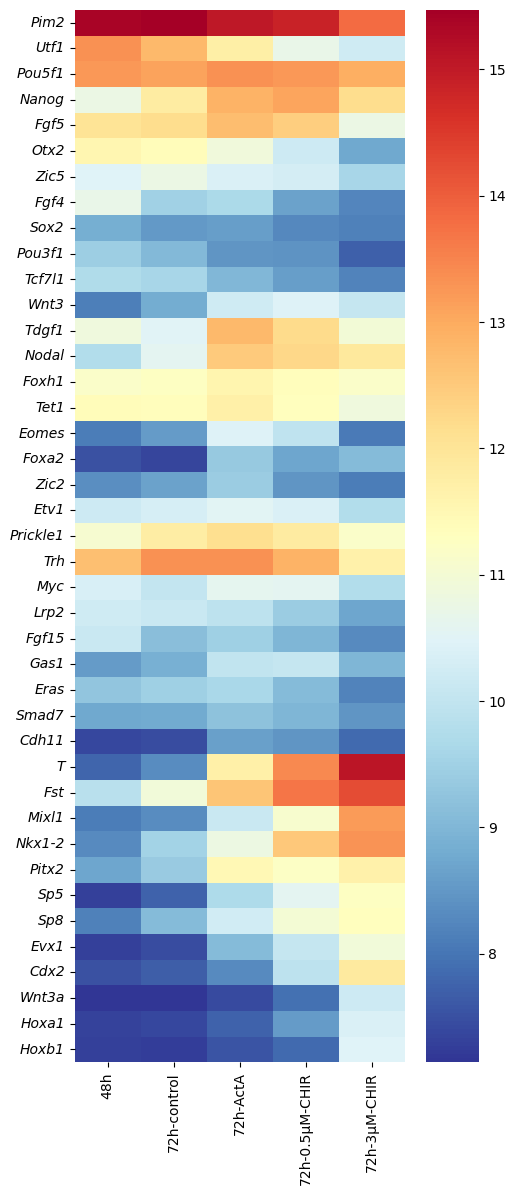

In [ ]:
# retain samples of interest
d_s = df1.loc[[i in retain for i in df1.index],markers['heatmap_72h']]
d_s_mean = d_s.groupby([i[:-2] for i in d_s.index]).mean()

fig,ax=plt.subplots(1,1, figsize=(len(retain)/3,len(markers['heatmap_72h'])/3))

sns.heatmap(
    d_s_mean.loc[['48h','72h-3μMc-DMSO','72h-high-ActA',
                  '72h-0.5μM-CHIR','72h-3μM-CHIR']].transpose(),
    cmap="RdYlBu_r",
    ax=ax
)
ax.set_xticklabels(['48h','72h-control','72h-ActA','72h-0.5μM-CHIR','72h-3μM-CHIR'],color='black')
ax.tick_params('y', labelrotation=0, color='black')
ax.set_yticklabels(ax.get_yticklabels(), style='italic')

plt.savefig(f"{plots_dir}/bulk_analysis_heatmap_act_vs_chir_72h.{save_format}",bbox_inches="tight",transparent=True)

# 96h

In [ ]:
retain=[
        '96h-high-ActA_1','96h-high-ActA_2','96h-high-ActA_3',
        '96h-3μM-CHIR_1','96h-3μM-CHIR_2','96h-3μM-CHIR_3']

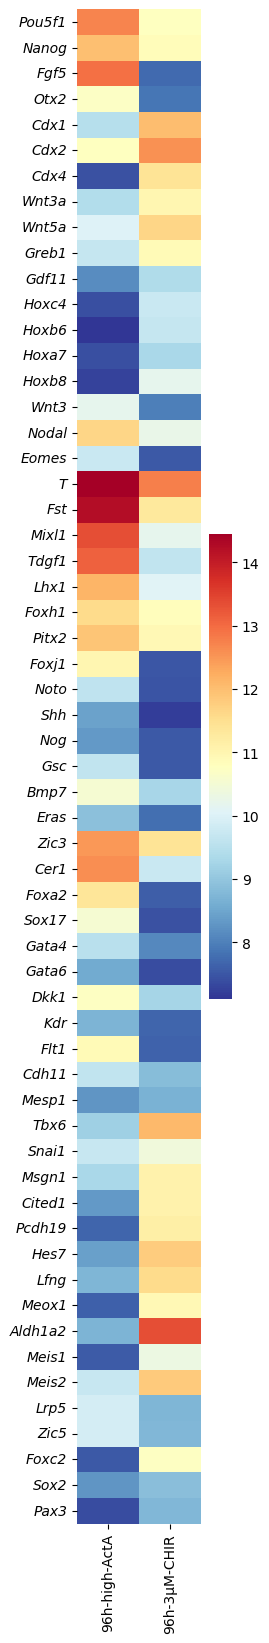

In [ ]:
# retain samples of interest
d_s = df1.loc[[i in retain for i in df1.index],markers['heatmap_96h']]
d_s_mean = d_s.groupby([i[:-2] for i in d_s.index]).mean()

fig,ax=plt.subplots(1,1, figsize=(len(retain)/3,len(markers['heatmap_96h'])/3))

sns.heatmap(
    d_s_mean.loc[['96h-high-ActA','96h-3μM-CHIR']].transpose(),
    cmap="RdYlBu_r",
    ax=ax
)
ax.set_xticklabels(['96h-high-ActA','96h-3μM-CHIR'],color='black')
ax.tick_params('y', labelrotation=0, color='black')
ax.set_yticklabels(ax.get_yticklabels(), style='italic')

plt.savefig(f"{plots_dir}/bulk_analysis_heatmap_act_vs_chir_96h.{save_format}",bbox_inches="tight",transparent=True)

# 120h

In [ ]:
retain = [
        '120h-high-ActA_1','120h-high-ActA_2','120h-high-ActA_3',
        '120h-3μM-CHIR_1','120h-3μM-CHIR_2','120h-3μM-CHIR_3']

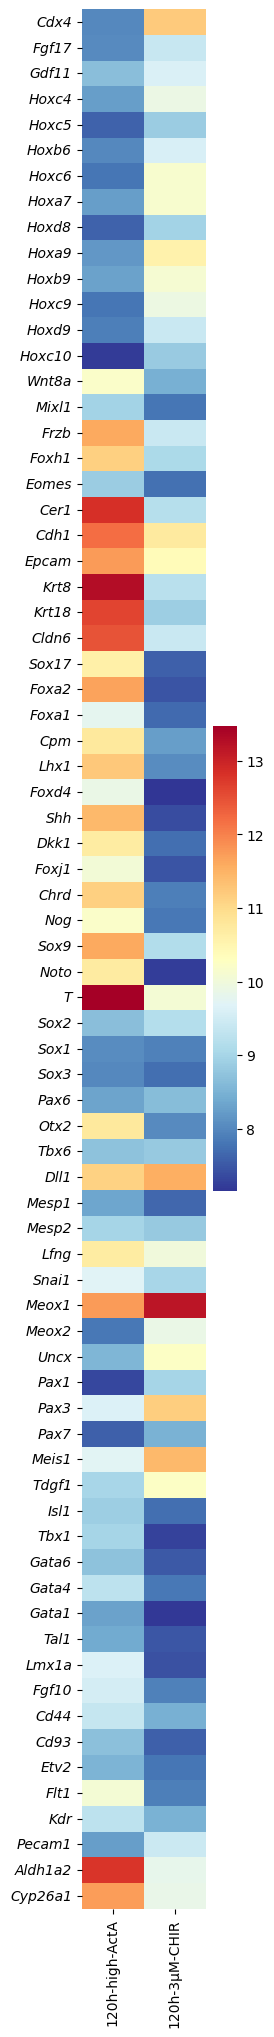

In [ ]:
# retain samples of interest
d_s = df1.loc[[i in retain for i in df1.index],markers['heatmap_120h']]
d_s_mean = d_s.groupby([i[:-2] for i in d_s.index]).mean()

fig,ax=plt.subplots(1,1, figsize=(len(retain)/3,len(markers['heatmap_120h'])/3))

sns.heatmap(
    d_s_mean.loc[['120h-high-ActA','120h-3μM-CHIR']].transpose(),
    cmap="RdYlBu_r",
    ax=ax
)
ax.set_xticklabels(['120h-high-ActA','120h-3μM-CHIR'],color='black')
ax.tick_params('y', labelrotation=0, color='black')
ax.set_yticklabels(ax.get_yticklabels(), style='italic')

plt.savefig(f"{plots_dir}/bulk_analysis_heatmap_act_vs_chir_120h.{save_format}",bbox_inches="tight",transparent=True)

## 144h

In [ ]:
retain = ['144h-low-ActA_1','144h-low-ActA_2','144h-low-ActA_3',
        '144h-high-ActA_1','144h-high-ActA_2','144h-high-ActA_3']

In [ ]:
# # retain samples of interest
# d_s = df1.loc[[i in retain for i in df1.index],markers['heatmap_144h']]
# d_s_mean = d_s.groupby([i[:-2] for i in d_s.index]).mean()

# fig,ax=plt.subplots(1,1, figsize=(len(retain)/3,len(markers['heatmap_14'])/3))

# sns.heatmap(
#     d_s_mean.loc[['144h-low-ActA','144h-high-ActA']].transpose(),
#     cmap="RdYlBu_r",
#     ax=ax
# )
# ax.set_xticklabels(['144h-low-ActA','144h-high-ActA'],color='black')
# ax.tick_params('y', labelrotation=0, color='black')
# ax.set_yticklabels(ax.get_yticklabels(), style='italic')

# plt.savefig(f"results/bulk_analysis_heatmap_act_vs_chir_144h.{save_format}",bbox_inches="tight",transparent=True)